# Importation of Libraries

In [7]:
# Standard Python libraries
from pathlib import Path
import json
import platform
import warnings

# Data manipulation
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data splitting and model tuning
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    train_test_split,
)

# Data preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Class-imbalance handling
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Probability calibration
from sklearn.calibration import CalibratedClassifierCV

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    brier_score_loss,
    cohen_kappa_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
)

# Saving the final model
import joblib

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

## Data importation

In [9]:
data=pd.read_excel("U5_S_Data.xlsx")
data.head()

,Child is Alive,Maternal Education,Maternal Health Status,Wealth Index,Maternal Age at 1st Birth,Birth Order,Child is Twin,Child Sex,Preceeding Birth Interval,Birth Assisstance,Antenatal Care Visits,Birth Weight,Residence,Marital Status
0,Yes,No education,Very good,Richer,21,4,Single birth,Male,92.0,No,5.0,4000.0,Urban,Married
1,Yes,Secondary,Good,Richest,19,5,Single birth,Female,30.0,No,4.0,4500.0,Urban,Married
2,Yes,Secondary,Good,Richer,19,3,Single birth,Male,23.0,Yes,5.0,2900.0,Urban,Married
3,Yes,Secondary,Good,Richest,26,1,Single birth,Female,38.0,No,2.0,2800.0,Urban,Married
4,Yes,Secondary,Moderate,Richest,32,2,Single birth,Male,23.0,Yes,3.0,4400.0,Urban,Married


# Data Inspection

In [11]:
data.tail()

,Child is Alive,Maternal Education,Maternal Health Status,Wealth Index,Maternal Age at 1st Birth,Birth Order,Child is Twin,Child Sex,Preceeding Birth Interval,Birth Assisstance,Antenatal Care Visits,Birth Weight,Residence,Marital Status
5110,Yes,Primary,Good,Poorest,19,2,Single birth,Male,31.0,No,4.0,2700.0,Rural,Married
5111,No,No education,Good,Poorest,20,5,Single birth,Male,33.0,No,6.0,3500.0,Rural,Widowed
5112,Yes,No education,Good,Poorest,20,4,Single birth,Female,37.0,No,6.0,3400.0,Rural,Widowed
5113,Yes,Primary,Good,Middle,19,1,Single birth,Female,NaN,Yes,5.0,3400.0,Urban,Married
5114,Yes,No education,Good,Poorest,18,1,Single birth,Male,19.0,Yes,4.0,3000.0,Urban,Married


In [12]:
data.shape

(5115, 14)

## Inspect column, rows and data types

In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5115 entries, 0 to 5114
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Child is Alive             5115 non-null   object 
 1   Maternal Education         5115 non-null   object 
 2   Maternal Health Status     5115 non-null   object 
 3   Wealth Index               5115 non-null   object 
 4   Maternal Age at 1st Birth  5115 non-null   int64  
 5   Birth Order                5115 non-null   int64  
 6   Child is Twin              5115 non-null   object 
 7   Child Sex                  5115 non-null   object 
 8   Preceeding Birth Interval  5092 non-null   float64
 9   Birth Assisstance          5100 non-null   object 
 10  Antenatal Care Visits      5025 non-null   float64
 11  Birth Weight               5058 non-null   float64
 12  Residence                  5115 non-null   object 
 13  Marital Status             5115 non-null   objec

## Assess missing values

In [16]:
missing_summary = pd.DataFrame({
    "Missing values": data.isna().sum(),
    "Missing percentage": data.isna().mean() * 100,
})

missing_summary = missing_summary.sort_values(
    "Missing values", ascending=False
)

display(missing_summary.round(2))

,Missing values,Missing percentage
Antenatal Care Visits,90,1.76
Birth Weight,57,1.11
Preceeding Birth Interval,23,0.45
Birth Assisstance,15,0.29
Child is Alive,0,0.00
Maternal Education,0,0.00
Maternal Health Status,0,0.00
Wealth Index,0,0.00
Maternal Age at 1st Birth,0,0.00
Birth Order,0,0.00


## Check Duplicates

In [18]:
data.duplicated().sum()

0

## Examine Outcome Distribution

In [20]:
outcome_summary = pd.DataFrame({
    "Frequency": data["Child is Alive"].value_counts(dropna=False),
    "Percentage": (
        data["Child is Alive"].value_counts(dropna=False, normalize=True) * 100
    ),
})

display(outcome_summary.round(2))

,Frequency,Percentage
Child is Alive,,
Yes,3887,75.99
No,1228,24.01


## Inspect numerical ranges

In [22]:
numerical_columns_raw = [
    "Maternal Age at 1st Birth",
    "Preceeding Birth Interval",
    "Antenatal Care Visits",
    "Birth Weight",
]

numerical_summary = data[numerical_columns_raw].describe().T
display(numerical_summary.round(2))

,count,mean,std,min,25%,50%,75%,max
Maternal Age at 1st Birth,5115.0,19.84,3.90,11.0,17.0,19.0,22.0,39.0
Preceeding Birth Interval,5092.0,37.91,25.88,8.0,22.0,30.0,46.0,208.0
Antenatal Care Visits,5025.0,3.83,1.88,0.0,3.0,4.0,5.0,12.0
Birth Weight,5058.0,3168.24,604.54,600.0,2900.0,3100.0,3500.0,6000.0


## Inspect categorical variables

In [24]:
categorical_columns_raw = [
    "Maternal Education",
    "Maternal Health Status",
    "Wealth Index",
    "Birth Order",
    "Child is Twin",
    "Child Sex",
    "Birth Assisstance",
    "Residence",
    "Marital Status",
]

for column in categorical_columns_raw:
    print
    display(data[column].value_counts(dropna=False).to_frame("Frequency"))

,Frequency
Maternal Education,
No education,2825
Primary,1435
Secondary,635
Higher,220


,Frequency
Maternal Health Status,
Good,3339
Very good,1025
Moderate,640
Bad,108
Very bad,3


,Frequency
Wealth Index,
Poorest,2703
Richer,823
Middle,669
Poorer,527
Richest,393


,Frequency
Birth Order,
1,1019
2,868
3,734
4,606
5,507
6,426
7,369
8,245
9,169


,Frequency
Child is Twin,
Single birth,4979
2nd of multiple,68
1st of multiple,68


,Frequency
Child Sex,
Male,2592
Female,2523


,Frequency
Birth Assisstance,
Yes,2728
No,2372
NaN,15


,Frequency
Residence,
Rural,3025
Urban,2090


,Frequency
Marital Status,
Married,4482
No longer living together/separated,150
Divorced,143
Never in union,142
Living with partner,127
Widowed,71


## Rename the Variables

In [26]:
rename_map = {
    "Child is Alive": "child_alive",
    "Maternal Education": "maternal_education",
    "Maternal Health Status": "maternal_health_status",
    "Wealth Index": "wealth_index",
    "Maternal Age at 1st Birth": "maternal_age_first_birth",
    "Birth Order": "birth_order",
    "Child is Twin": "multiple_birth",
    "Child Sex": "child_sex",
    "Preceeding Birth Interval": "birth_interval",
    "Preceding Birth Interval": "birth_interval",
    "Birth Assisstance": "birth_assistance",
    "Birth Assistance": "birth_assistance",
    "Antenatal Care Visits": "anc_visits",
    "Birth Weight": "birth_weight",
    "Residence": "residence",
    "Marital Status": "marital_status",
}

data = data.rename(columns=rename_map)

In [27]:
print(data.columns.tolist())

['child_alive', 'maternal_education', 'maternal_health_status', 'wealth_index', 'maternal_age_first_birth', 'birth_order', 'multiple_birth', 'child_sex', 'birth_interval', 'birth_assistance', 'anc_visits', 'birth_weight', 'residence', 'marital_status']


## Create the outcome variable

In [29]:
# Define the outcome encoding.
target_mapping = {
    "Yes": 0,  # Child survived/is alive
    "No": 1,   # Under-five death
}

data["under_five_mortality"] = data["child_alive"].map(
    target_mapping
)

# Check whether any target values failed to map.
unmapped_target = data.loc[
    data["under_five_mortality"].isna(),
    "child_alive"
].unique()

if len(unmapped_target) > 0:
    raise ValueError(
        f"Unrecognized outcome values were found: {unmapped_target}"
    )

# Store the outcome as an integer.
data["under_five_mortality"] = (
    data["under_five_mortality"].astype(int)
)

# Remove the original target column.
data = data.drop(columns=["child_alive"])


## Confirm the target distribution

In [31]:
target_summary = pd.DataFrame({
    "Frequency": data["under_five_mortality"].value_counts(),
    "Percentage": (
        data["under_five_mortality"]
        .value_counts(normalize=True)
        .mul(100)
    )
})

target_summary.index = target_summary.index.map({
    0: "Alive (0)",
    1: "Under-five death (1)",
})

display(target_summary.round(2))

,Frequency,Percentage
under_five_mortality,,
Alive (0),3887,75.99
Under-five death (1),1228,24.01


## Define the predictor groups

In [33]:
target = "under_five_mortality"

continuous_vars = [
    "maternal_age_first_birth",
    "birth_interval",
    "anc_visits",
    "birth_weight",
]

categorical_vars = [
    "maternal_education",
    "maternal_health_status",
    "birth_order",
    "wealth_index",
    "multiple_birth",
    "child_sex",
    "birth_assistance",
    "residence",
    "marital_status",
]

predictor_vars = continuous_vars + categorical_vars

## Convert the continuous predictors to numeric values

In [35]:
for column in continuous_vars:
    data[column] = pd.to_numeric(
        data[column],
        errors="coerce"
    )

# Birth order is an ordered count but will be modelled categorically.
data["birth_order"] = pd.to_numeric(
    data["birth_order"],
    errors="coerce"
).astype("Int64")

## Clean categorical text

In [37]:
string_categorical_vars = [
    column
    for column in categorical_vars
    if column != "birth_order"
]

for column in string_categorical_vars:
    data[column] = (
        data[column]
        .astype("string")
        .str.strip()
        .replace("", pd.NA)
    )

## Review missing values after type conversion

In [39]:
missing_after_cleaning = pd.DataFrame({
    "Missing values": data.isna().sum(),
    "Missing percentage": (
        data.isna().mean() * 100
    ),
})

missing_after_cleaning = missing_after_cleaning.sort_values(
    "Missing values",
    ascending=False
)

display(missing_after_cleaning.round(2))

,Missing values,Missing percentage
anc_visits,90,1.76
birth_weight,57,1.11
birth_interval,23,0.45
birth_assistance,15,0.29
maternal_education,0,0.00
maternal_health_status,0,0.00
wealth_index,0,0.00
maternal_age_first_birth,0,0.00
birth_order,0,0.00
multiple_birth,0,0.00


## Review numerical ranges

In [41]:
numerical_range_check = data[continuous_vars].agg(
    ["count", "min", "median", "mean", "max"]
).T

display(numerical_range_check.round(2))

,count,min,median,mean,max
maternal_age_first_birth,5115.0,11.0,19.0,19.84,39.0
birth_interval,5092.0,8.0,30.0,37.91,208.0
anc_visits,5025.0,0.0,4.0,3.83,12.0
birth_weight,5058.0,600.0,3100.0,3168.24,6000.0


## Review Categorical values

In [43]:
for column in categorical_vars:
    print(f"\n{'=' * 60}")
    print(f"Variable: {column}")
    print(f"{'=' * 60}")

    category_summary = pd.DataFrame({
        "Frequency": data[column].value_counts(dropna=False),
        "Percentage": (
            data[column]
            .value_counts(dropna=False, normalize=True)
            .mul(100)
        ),
    })

    display(category_summary.round(2))


Variable: maternal_education


,Frequency,Percentage
maternal_education,,
No education,2825,55.23
Primary,1435,28.05
Secondary,635,12.41
Higher,220,4.3



Variable: maternal_health_status


,Frequency,Percentage
maternal_health_status,,
Good,3339,65.28
Very good,1025,20.04
Moderate,640,12.51
Bad,108,2.11
Very bad,3,0.06



Variable: birth_order


,Frequency,Percentage
birth_order,,
1,1019,19.92
2,868,16.97
3,734,14.35
4,606,11.85
5,507,9.91
6,426,8.33
7,369,7.21
8,245,4.79
9,169,3.3



Variable: wealth_index


,Frequency,Percentage
wealth_index,,
Poorest,2703,52.84
Richer,823,16.09
Middle,669,13.08
Poorer,527,10.3
Richest,393,7.68



Variable: multiple_birth


,Frequency,Percentage
multiple_birth,,
Single birth,4979,97.34
2nd of multiple,68,1.33
1st of multiple,68,1.33



Variable: child_sex


,Frequency,Percentage
child_sex,,
Male,2592,50.67
Female,2523,49.33



Variable: birth_assistance


,Frequency,Percentage
birth_assistance,,
Yes,2728,53.33
No,2372,46.37
<NA>,15,0.29



Variable: residence


,Frequency,Percentage
residence,,
Rural,3025,59.14
Urban,2090,40.86



Variable: marital_status


,Frequency,Percentage
marital_status,,
Married,4482,87.62
No longer living together/separated,150,2.93
Divorced,143,2.8
Never in union,142,2.78
Living with partner,127,2.48
Widowed,71,1.39


## Data Dictionary

In [45]:
data_dictionary = pd.DataFrame([
    {
        "Variable": "under_five_mortality",
        "Description": "Under-five mortality outcome",
        "Role": "Target",
        "Type": "Binary",
        "Coding or unit": "0 = alive; 1 = death",
    },
    {
        "Variable": "maternal_age_first_birth",
        "Description": "Maternal age at first birth",
        "Role": "Predictor",
        "Type": "Continuous",
        "Coding or unit": "Years",
    },
    {
        "Variable": "birth_interval",
        "Description": "Preceding birth interval",
        "Role": "Predictor",
        "Type": "Continuous",
        "Coding or unit": "Months",
    },
    {
        "Variable": "anc_visits",
        "Description": "Number of antenatal care visits",
        "Role": "Predictor",
        "Type": "Continuous",
        "Coding or unit": "Number of visits",
    },
    {
        "Variable": "birth_weight",
        "Description": "Child's birth weight",
        "Role": "Predictor",
        "Type": "Continuous",
        "Coding or unit": "Grams",
    },
    {
        "Variable": "maternal_education",
        "Description": "Highest maternal education level",
        "Role": "Predictor",
        "Type": "Categorical",
        "Coding or unit": "Education category",
    },
    {
        "Variable": "maternal_health_status",
        "Description": "Maternal health status",
        "Role": "Predictor",
        "Type": "Categorical",
        "Coding or unit": "Health-status category",
    },
    {
        "Variable": "birth_order",
        "Description": "Child's birth order",
        "Role": "Predictor",
        "Type": "Categorical/ordinal",
        "Coding or unit": "Birth-order number",
    },
    {
        "Variable": "wealth_index",
        "Description": "Household wealth index",
        "Role": "Predictor",
        "Type": "Categorical",
        "Coding or unit": "Wealth category",
    },
    {
        "Variable": "multiple_birth",
        "Description": "Single or multiple birth status",
        "Role": "Predictor",
        "Type": "Categorical",
        "Coding or unit": "Birth category",
    },
    {
        "Variable": "child_sex",
        "Description": "Sex of the child",
        "Role": "Predictor",
        "Type": "Categorical",
        "Coding or unit": "Female or male",
    },
    {
        "Variable": "birth_assistance",
        "Description": "Whether birth assistance was received",
        "Role": "Predictor",
        "Type": "Categorical",
        "Coding or unit": "Yes or no",
    },
    {
        "Variable": "residence",
        "Description": "Place of residence",
        "Role": "Predictor",
        "Type": "Categorical",
        "Coding or unit": "Rural or urban",
    },
    {
        "Variable": "marital_status",
        "Description": "Maternal marital status",
        "Role": "Predictor",
        "Type": "Categorical",
        "Coding or unit": "Marital-status category",
    },
])

display(data_dictionary)

,Variable,Description,Role,Type,Coding or unit
0,under_five_mortality,Under-five mortality outcome,Target,Binary,0 = alive; 1 = death
1,maternal_age_first_birth,Maternal age at first birth,Predictor,Continuous,Years
2,birth_interval,Preceding birth interval,Predictor,Continuous,Months
3,anc_visits,Number of antenatal care visits,Predictor,Continuous,Number of visits
4,birth_weight,Child's birth weight,Predictor,Continuous,Grams
5,maternal_education,Highest maternal education level,Predictor,Categorical,Education category
6,maternal_health_status,Maternal health status,Predictor,Categorical,Health-status category
7,birth_order,Child's birth order,Predictor,Categorical/ordinal,Birth-order number
8,wealth_index,Household wealth index,Predictor,Categorical,Wealth category
9,multiple_birth,Single or multiple birth status,Predictor,Categorical,Birth category


# Exploratory Data Analysis

## Visual style

In [48]:
sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette="deep"
)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["figure.dpi"] = 100

mortality_labels = {
    0: "Alive",
    1: "Under-five death",
}

# Create a separate dataframe for plots.
plot_data = data.copy()

plot_data["mortality_status"] = (
    plot_data[target].map(mortality_labels)
)

## Outcome Distribution
### Outcome Frequencies

In [50]:
outcome_distribution = (
    data[target]
    .value_counts()
    .sort_index()
    .rename(index=mortality_labels)
    .to_frame("Frequency")
)

outcome_distribution["Percentage"] = (
    outcome_distribution["Frequency"]
    / outcome_distribution["Frequency"].sum()
    * 100
)

display(outcome_distribution.round(2))

,Frequency,Percentage
under_five_mortality,,
Alive,3887,75.99
Under-five death,1228,24.01


### Plot the outcome distribution

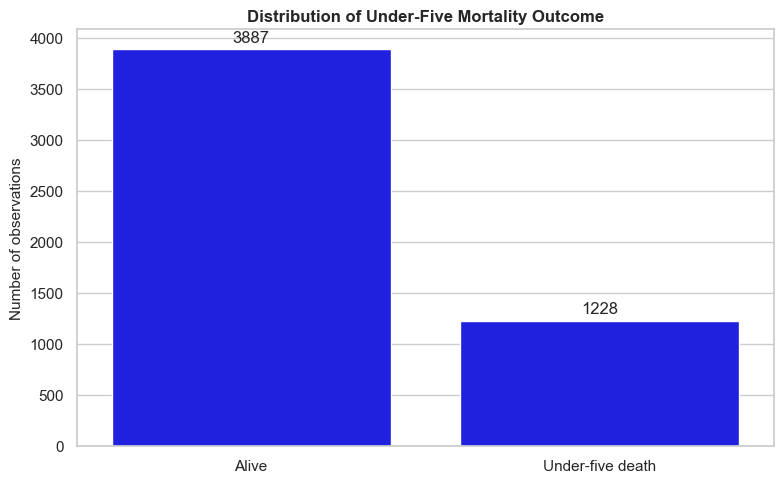

In [52]:
outcome_plot = outcome_distribution.reset_index()
outcome_plot.columns = [
    "Mortality status",
    "Frequency",
    "Percentage",
]

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=outcome_plot,
    x="Mortality status",
    y="Frequency",
    hue="Mortality status",
    palette=["Blue", "Blue"],
    legend=False,
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.title("Distribution of Under-Five Mortality Outcome")
plt.xlabel("")
plt.ylabel("Number of observations")
plt.tight_layout()
plt.show()

## Missing-Value Summary

In [54]:
missing_eda = pd.DataFrame({
    "Missing values": data[predictor_vars].isna().sum(),
    "Missing percentage": (
        data[predictor_vars].isna().mean() * 100
    ),
})

missing_eda = missing_eda.loc[
    missing_eda["Missing values"] > 0
].sort_values(
    "Missing percentage",
    ascending=False
)

display(missing_eda.round(2))

,Missing values,Missing percentage
anc_visits,90,1.76
birth_weight,57,1.11
birth_interval,23,0.45
birth_assistance,15,0.29


## Plot the missing percentages

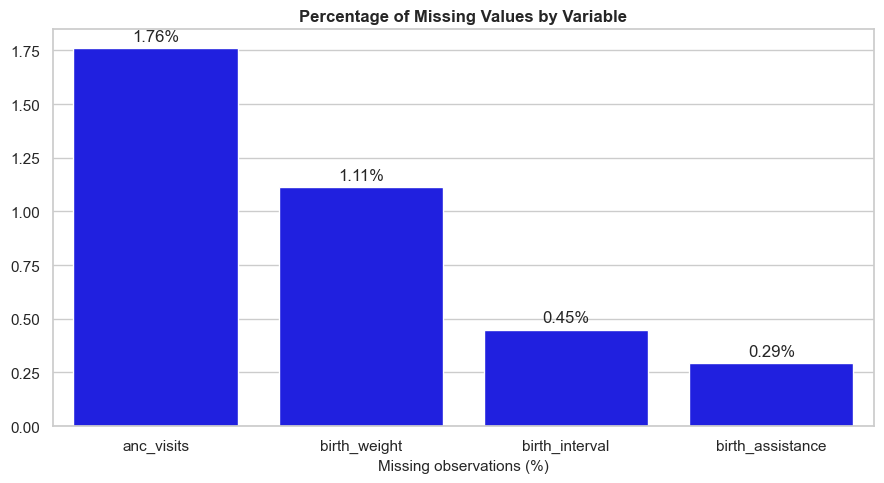

In [56]:
if not missing_eda.empty:
    missing_plot = (
        missing_eda
        .reset_index()
        .rename(columns={"index": "Variable"})
    )

    plt.figure(figsize=(9, 5))

    ax = sns.barplot(
        data=missing_plot,
        y="Missing percentage",
        x="Variable",
        color="Blue",
    )

    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f%%", padding=3)

    plt.title("Percentage of Missing Values by Variable")
    plt.xlabel("Missing observations (%)")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()
else:
    print("No missing predictor values were found.")

## Numerical Variable Analysis
### Descriptive statistics

In [58]:
numerical_descriptive = data[continuous_vars].describe().T

numerical_descriptive["missing"] = (
    data[continuous_vars].isna().sum()
)

numerical_descriptive["skewness"] = (
    data[continuous_vars].skew()
)

display(numerical_descriptive.round(2))

,count,mean,std,min,25%,50%,75%,max,missing,skewness
maternal_age_first_birth,5115.0,19.84,3.90,11.0,17.0,19.0,22.0,39.0,0,0.71
birth_interval,5092.0,37.91,25.88,8.0,22.0,30.0,46.0,208.0,23,2.17
anc_visits,5025.0,3.83,1.88,0.0,3.0,4.0,5.0,12.0,90,0.03
birth_weight,5058.0,3168.24,604.54,600.0,2900.0,3100.0,3500.0,6000.0,57,0.09


### Plot numerical distributions

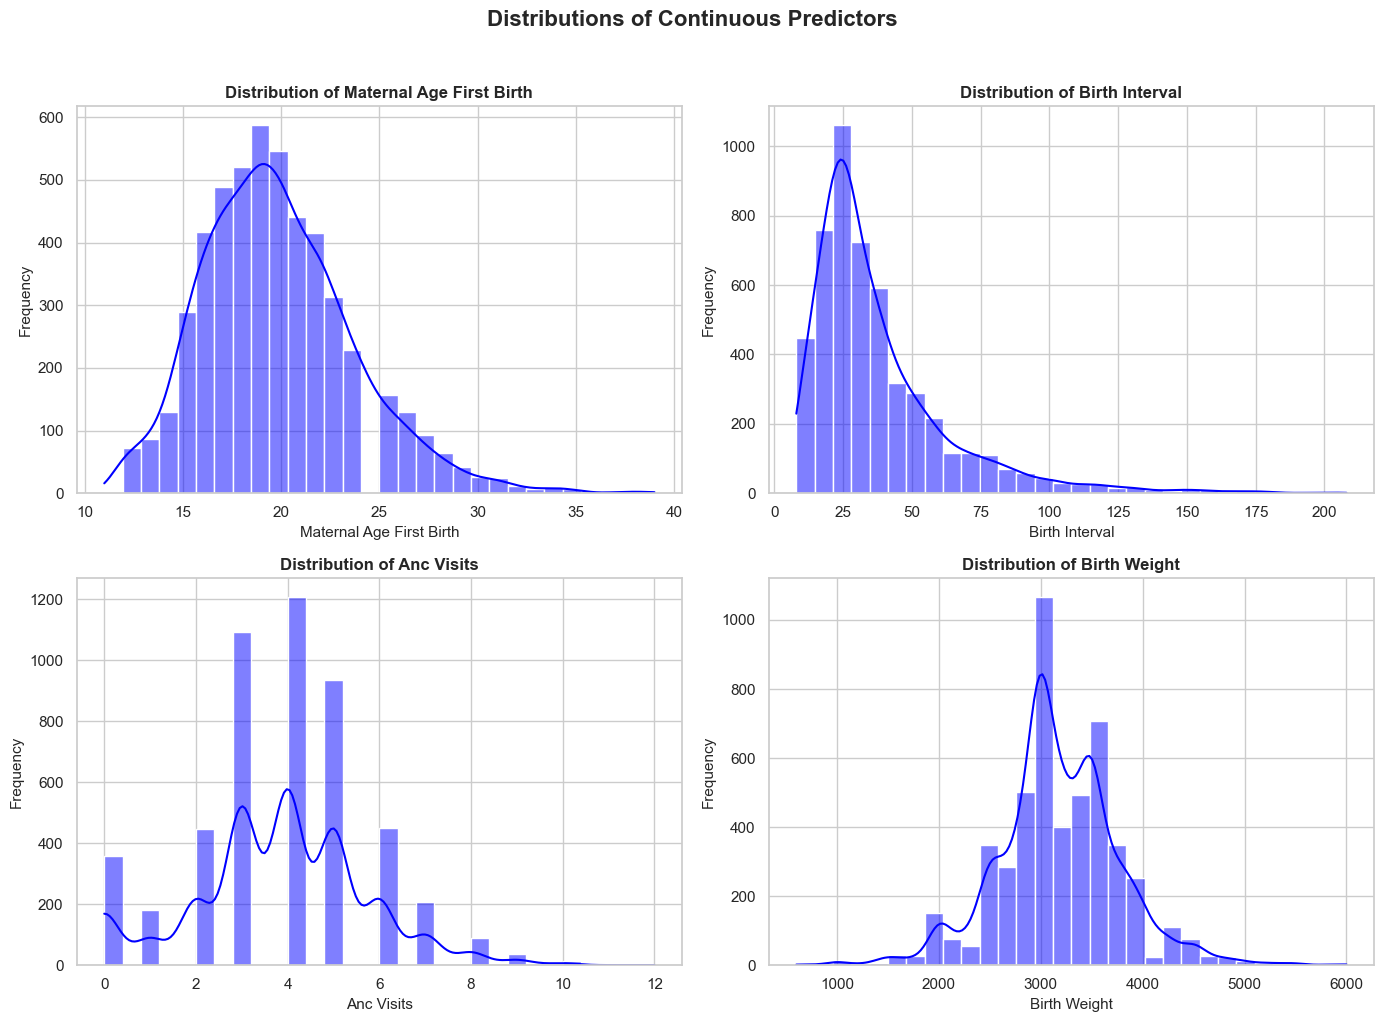

In [60]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(14, 10)
)

axes = axes.flatten()

for axis, column in zip(axes, continuous_vars):
    sns.histplot(
        data=data,
        x=column,
        bins=30,
        kde=True,
        color="Blue",
        ax=axis,
    )

    axis.set_title(
        f"Distribution of {column.replace('_', ' ').title()}"
    )
    axis.set_xlabel(column.replace("_", " ").title())
    axis.set_ylabel("Frequency")

plt.suptitle(
    "Distributions of Continuous Predictors",
    fontsize=16,
    fontweight="bold",
    y=1.02,
)

plt.tight_layout()
plt.show()

## Compare Numerical Variables by Outcome
### Box plots

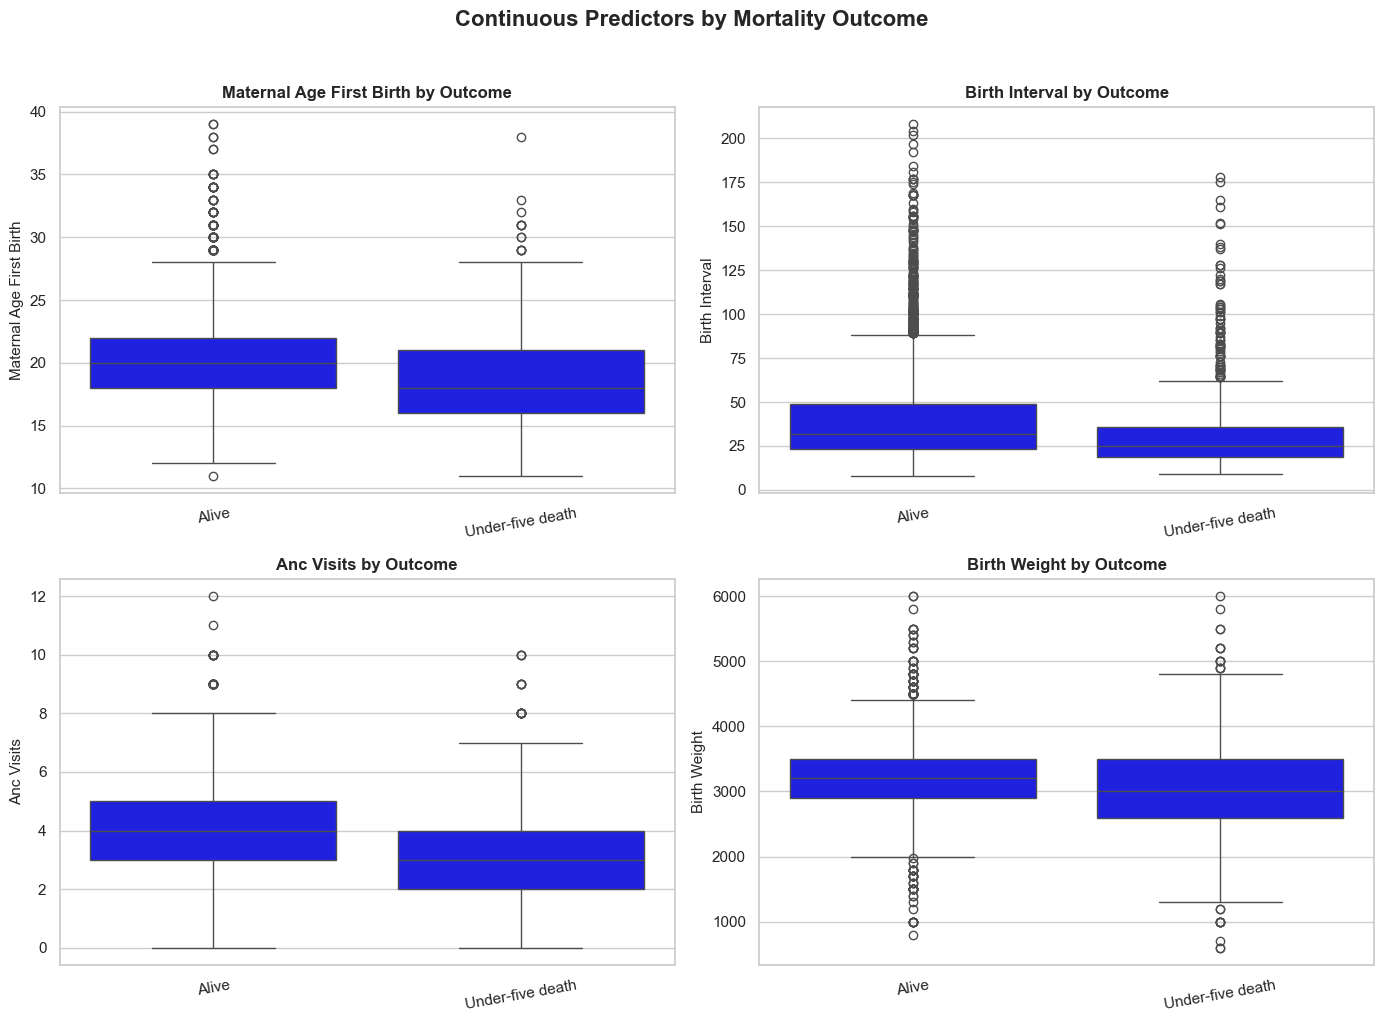

In [62]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(14, 10)
)

axes = axes.flatten()

for axis, column in zip(axes, continuous_vars):
    sns.boxplot(
        data=plot_data,
        x="mortality_status",
        y=column,
        hue="mortality_status",
        palette={
            "Alive": "Blue",
            "Under-five death": "Blue",
        },
        legend=False,
        ax=axis,
    )

    axis.set_title(
        f"{column.replace('_', ' ').title()} by Outcome"
    )
    axis.set_xlabel("")
    axis.set_ylabel(column.replace("_", " ").title())
    axis.tick_params(axis="x", rotation=10)

plt.suptitle(
    "Continuous Predictors by Mortality Outcome",
    fontsize=16,
    fontweight="bold",
    y=1.02,
)

plt.tight_layout()
plt.show()

### Numerical summaries by outcome

In [64]:
numerical_by_outcome = (
    data
    .groupby(target)[continuous_vars]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

numerical_by_outcome.index = numerical_by_outcome.index.map(
    mortality_labels
)

display(numerical_by_outcome)

maternal_age_first_birth                      \
                                        count   mean median   std   
under_five_mortality                                                
Alive                                    3887  20.25   20.0  3.87   
Under-five death                         1228  18.54   18.0  3.71   

                     birth_interval                      anc_visits        \
                              count   mean median    std      count  mean   
under_five_mortality                                                        
Alive                          3865  40.13   32.0  26.79       3817  4.12   
Under-five death               1227  30.91   25.0  21.33       1208  2.89   

                                  birth_weight                           
                     median   std        count     mean  median     std  
under_five_mortality                                                     
Alive                   4.0  1.76         3839  3199.82  3200.0  565.62  
Under-five death        3.0  1.93         1219  3068.81  3000.0  704.45

## Identify Potential Numerical Outliers
### IQR-based outlier summary

In [66]:
outlier_results = []

for column in continuous_vars:
    nonmissing_values = data[column].dropna()

    q1 = nonmissing_values.quantile(0.25)
    q3 = nonmissing_values.quantile(0.75)
    iqr = q3 - q1

    lower_limit = q1 - (1.5 * iqr)
    upper_limit = q3 + (1.5 * iqr)

    outlier_mask = (
        (data[column] < lower_limit)
        | (data[column] > upper_limit)
    )

    outlier_count = int(outlier_mask.sum())
    outlier_percentage = (
        outlier_count / len(data) * 100
    )

    outlier_results.append({
        "Variable": column,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower IQR limit": lower_limit,
        "Upper IQR limit": upper_limit,
        "Potential outliers": outlier_count,
        "Potential outliers (%)": outlier_percentage,
        "Observed minimum": nonmissing_values.min(),
        "Observed maximum": nonmissing_values.max(),
    })

outlier_summary = pd.DataFrame(outlier_results)

display(outlier_summary.round(2))

,Variable,Q1,Q3,IQR,Lower IQR limit,Upper IQR limit,Potential outliers,Potential outliers (%),Observed minimum,Observed maximum
0,maternal_age_first_birth,17.0,22.0,5.0,9.5,29.5,93,1.82,11.0,39.0
1,birth_interval,22.0,46.0,24.0,-14.0,82.0,329,6.43,8.0,208.0
2,anc_visits,3.0,5.0,2.0,0.0,8.0,53,1.04,0.0,12.0
3,birth_weight,2900.0,3500.0,600.0,2000.0,4400.0,238,4.65,600.0,6000.0


## Categorical Variable Analysis
### Display category frequencies

In [68]:
for column in categorical_vars:
    print("\n" + "=" * 70)
    print(column.replace("_", " ").title())
    print("=" * 70)

    frequency_table = pd.DataFrame({
        "Frequency": data[column].value_counts(dropna=False),
        "Percentage": (
            data[column]
            .value_counts(dropna=False, normalize=True)
            .mul(100)
        ),
    })

    display(frequency_table.round(2))


Maternal Education


,Frequency,Percentage
maternal_education,,
No education,2825,55.23
Primary,1435,28.05
Secondary,635,12.41
Higher,220,4.3



Maternal Health Status


,Frequency,Percentage
maternal_health_status,,
Good,3339,65.28
Very good,1025,20.04
Moderate,640,12.51
Bad,108,2.11
Very bad,3,0.06



Birth Order


,Frequency,Percentage
birth_order,,
1,1019,19.92
2,868,16.97
3,734,14.35
4,606,11.85
5,507,9.91
6,426,8.33
7,369,7.21
8,245,4.79
9,169,3.3



Wealth Index


,Frequency,Percentage
wealth_index,,
Poorest,2703,52.84
Richer,823,16.09
Middle,669,13.08
Poorer,527,10.3
Richest,393,7.68



Multiple Birth


,Frequency,Percentage
multiple_birth,,
Single birth,4979,97.34
2nd of multiple,68,1.33
1st of multiple,68,1.33



Child Sex


,Frequency,Percentage
child_sex,,
Male,2592,50.67
Female,2523,49.33



Birth Assistance


,Frequency,Percentage
birth_assistance,,
Yes,2728,53.33
No,2372,46.37
<NA>,15,0.29



Residence


,Frequency,Percentage
residence,,
Rural,3025,59.14
Urban,2090,40.86



Marital Status


,Frequency,Percentage
marital_status,,
Married,4482,87.62
No longer living together/separated,150,2.93
Divorced,143,2.8
Never in union,142,2.78
Living with partner,127,2.48
Widowed,71,1.39


## Mortality Rates Across Categories
### Create categorical mortality tables

In [70]:
categorical_mortality_tables = {}

for column in categorical_vars:
    summary = (
        data
        .groupby(column, dropna=False)[target]
        .agg(
            Total="size",
            Deaths="sum",
            Mortality_rate="mean",
        )
        .reset_index()
    )

    summary["Alive"] = (
        summary["Total"] - summary["Deaths"]
    )

    summary["Mortality percentage"] = (
        summary["Mortality_rate"] * 100
    )

    summary = summary.sort_values(
        "Mortality percentage",
        ascending=False,
    )

    categorical_mortality_tables[column] = summary

    print("\n" + "=" * 70)
    print(f"Mortality by {column.replace('_', ' ').title()}")
    print("=" * 70)

    display(
        summary[
            [
                column,
                "Total",
                "Alive",
                "Deaths",
                "Mortality percentage",
            ]
        ].round(2)
    )


Mortality by Maternal Education


,maternal_education,Total,Alive,Deaths,Mortality percentage
1,No education,2825,1737,1088,38.51
2,Primary,1435,1307,128,8.92
3,Secondary,635,623,12,1.89
0,Higher,220,220,0,0.00



Mortality by Maternal Health Status


,maternal_health_status,Total,Alive,Deaths,Mortality percentage
0,Bad,108,59,49,45.37
3,Very bad,3,2,1,33.33
2,Moderate,640,429,211,32.97
1,Good,3339,2528,811,24.29
4,Very good,1025,869,156,15.22



Mortality by Birth Order


,birth_order,Total,Alive,Deaths,Mortality percentage
10,11,43,14,29,67.44
12,13,9,3,6,66.67
9,10,98,36,62,63.27
11,12,20,8,12,60.00
8,9,169,84,85,50.30
6,7,369,192,177,47.97
7,8,245,129,116,47.35
5,6,426,273,153,35.92
4,5,507,365,142,28.01
3,4,606,482,124,20.46



Mortality by Wealth Index


,wealth_index,Total,Alive,Deaths,Mortality percentage
2,Poorest,2703,1639,1064,39.36
1,Poorer,527,453,74,14.04
0,Middle,669,610,59,8.82
3,Richer,823,792,31,3.77
4,Richest,393,393,0,0.00



Mortality by Multiple Birth


,multiple_birth,Total,Alive,Deaths,Mortality percentage
1,2nd of multiple,68,35,33,48.53
0,1st of multiple,68,38,30,44.12
2,Single birth,4979,3814,1165,23.40



Mortality by Child Sex


,child_sex,Total,Alive,Deaths,Mortality percentage
1,Male,2592,1923,669,25.81
0,Female,2523,1964,559,22.16



Mortality by Birth Assistance


,birth_assistance,Total,Alive,Deaths,Mortality percentage
0,No,2372,1574,798,33.64
1,Yes,2728,2299,429,15.73
2,<NA>,15,14,1,6.67



Mortality by Residence


,residence,Total,Alive,Deaths,Mortality percentage
0,Rural,3025,2018,1007,33.29
1,Urban,2090,1869,221,10.57



Mortality by Marital Status


,marital_status,Total,Alive,Deaths,Mortality percentage
5,Widowed,71,40,31,43.66
0,Divorced,143,106,37,25.87
2,Married,4482,3377,1105,24.65
4,No longer living together/separated,150,123,27,18.00
3,Never in union,142,126,16,11.27
1,Living with partner,127,115,12,9.45


### Plot categorical mortality rates

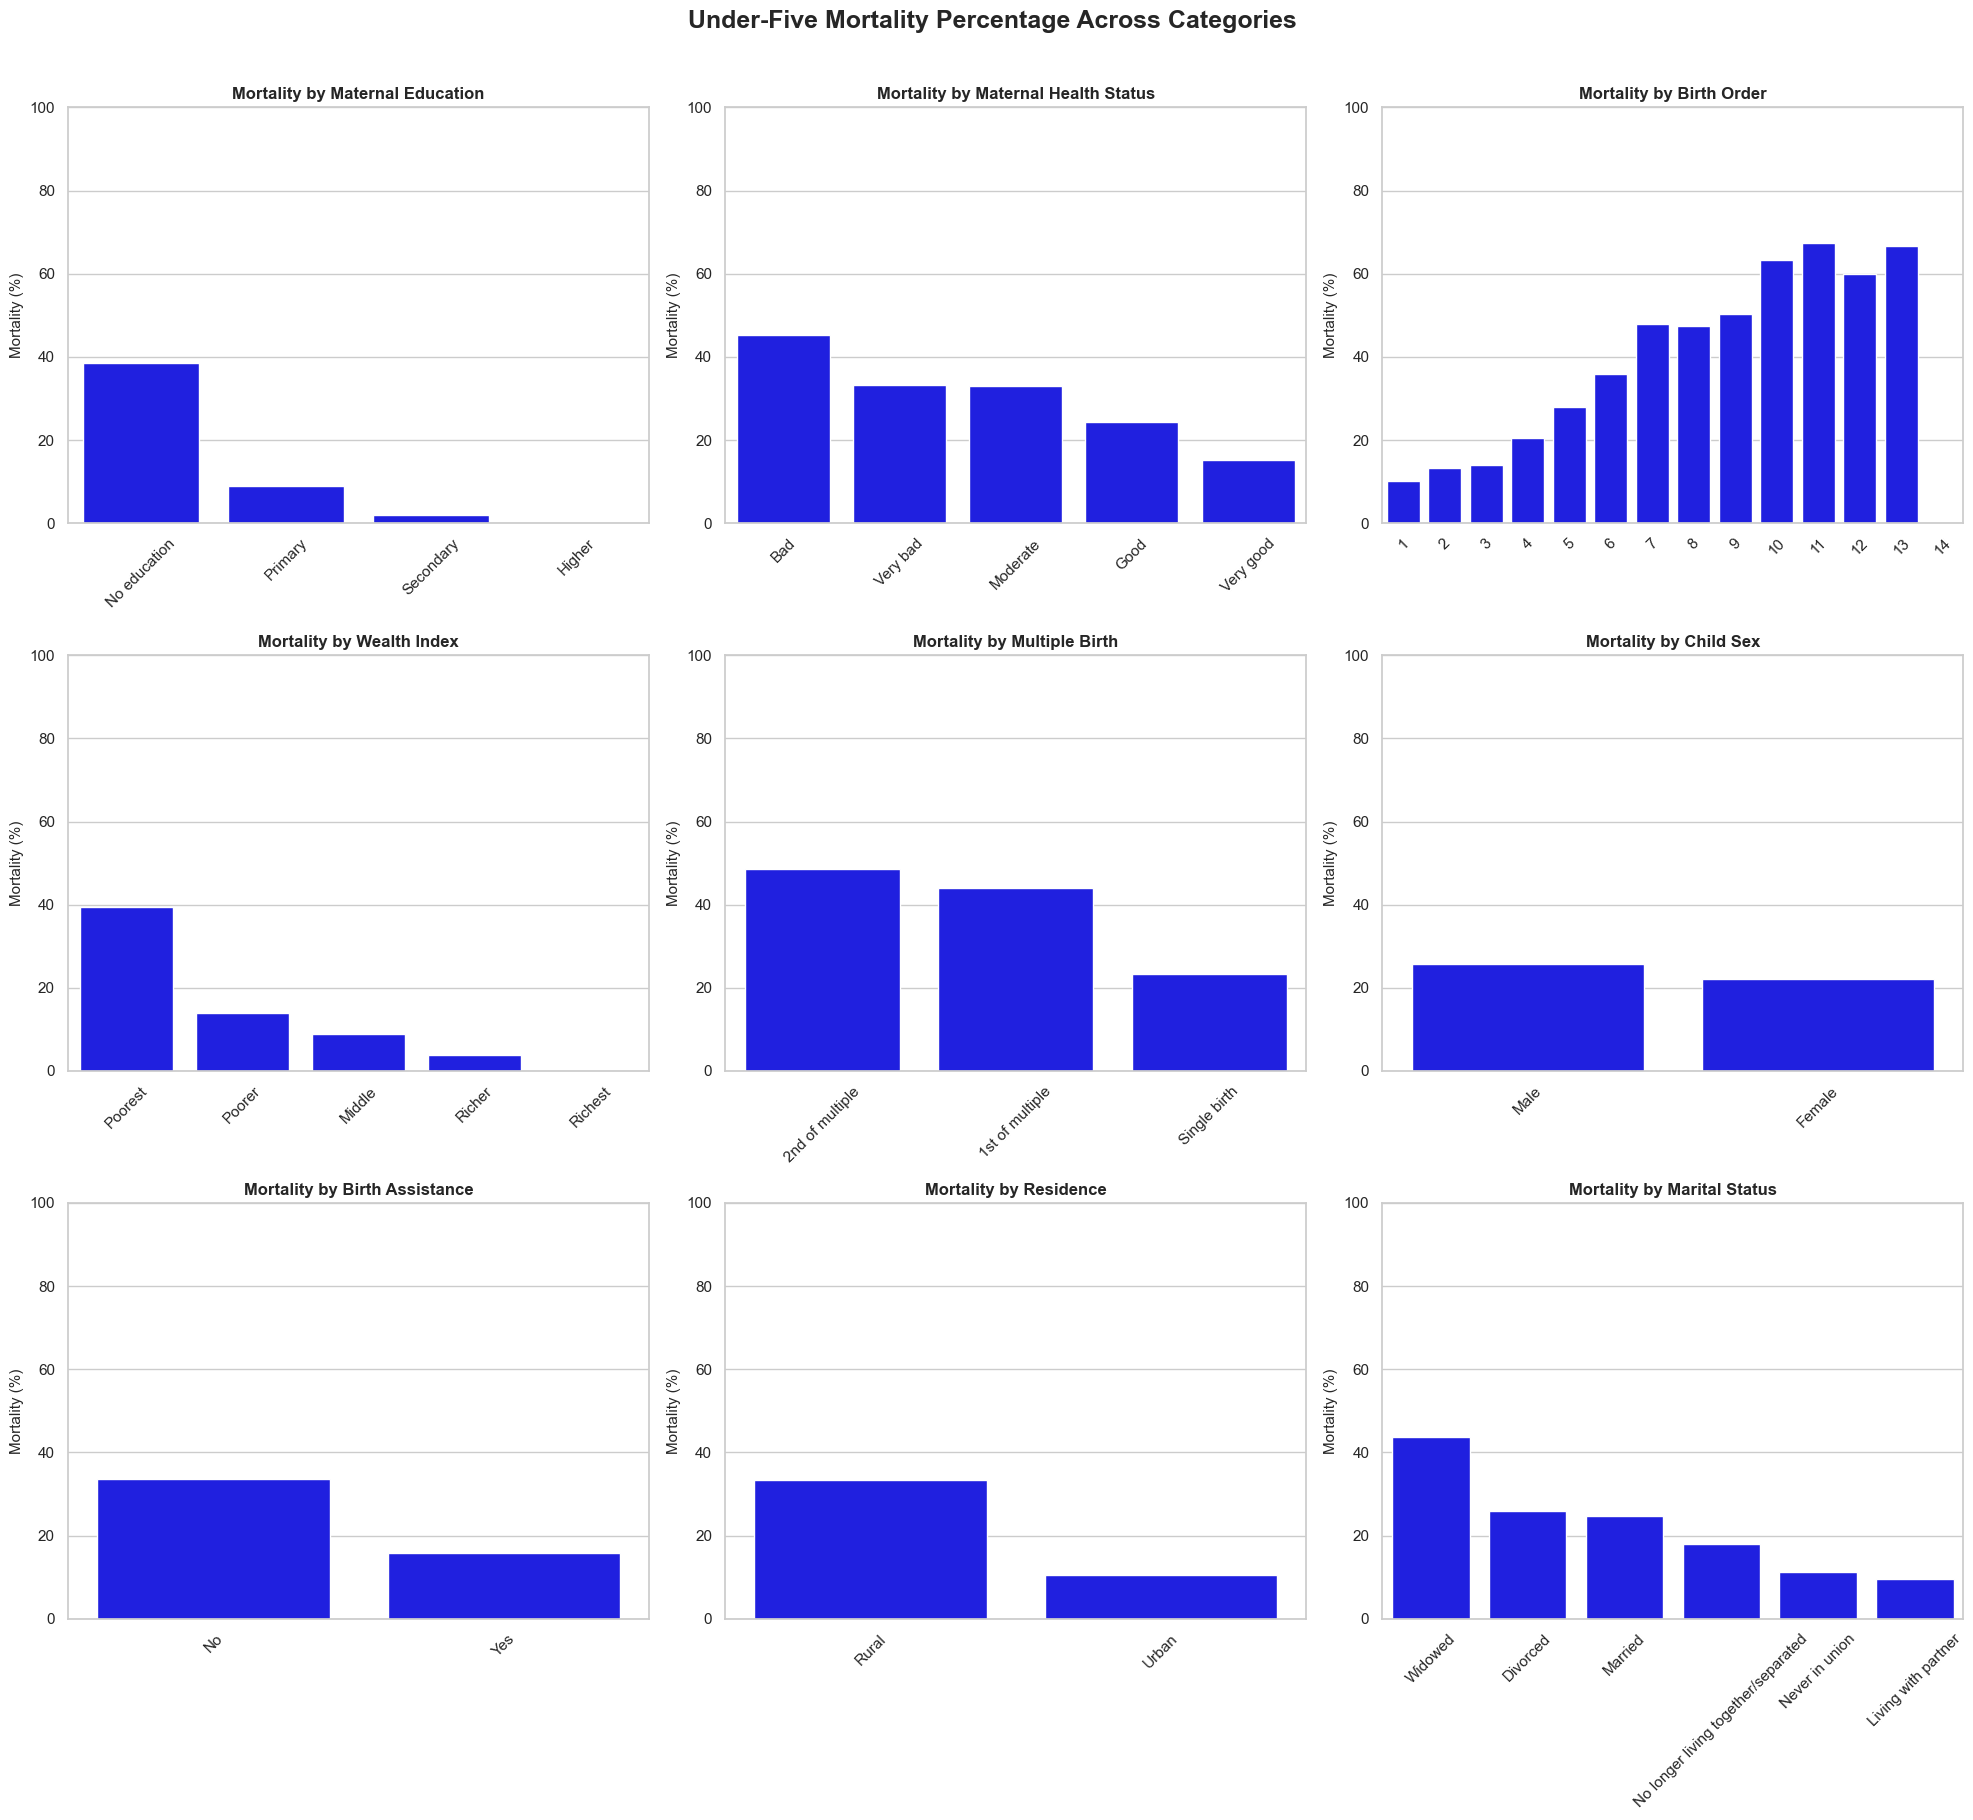

In [72]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(20, 18)
)

axes = axes.flatten()

for axis, column in zip(axes, categorical_vars):
    summary = categorical_mortality_tables[column].copy()

    sns.barplot(
        data=summary,
        x=column,
        y="Mortality percentage",
        color="blue",
        ax=axis,
    )

    axis.set_title(
        f"Mortality by {column.replace('_', ' ').title()}"
    )
    axis.set_xlabel("")
    axis.set_ylabel("Mortality (%)")
    axis.tick_params(axis="x", rotation=45)

    # Use the same scale to make charts comparable.
    axis.set_ylim(0, 100)

plt.suptitle(
    "Under-Five Mortality Percentage Across Categories",
    fontsize=18,
    fontweight="bold",
    y=1.01,
)

plt.tight_layout()
plt.show()

## Correlation Analysis
### Calculate the correlation matrix

In [74]:
correlation_variables = continuous_vars + [target]

correlation_matrix = (
    data[correlation_variables]
    .corr(method="pearson")
)

display(correlation_matrix.round(3))

,maternal_age_first_birth,birth_interval,anc_visits,birth_weight,under_five_mortality
maternal_age_first_birth,1.000,0.005,0.039,-0.004,-0.187
birth_interval,0.005,1.000,0.081,0.011,-0.152
anc_visits,0.039,0.081,1.000,-0.014,-0.281
birth_weight,-0.004,0.011,-0.014,1.000,-0.093
under_five_mortality,-0.187,-0.152,-0.281,-0.093,1.000


### Plot the correlation heatmap

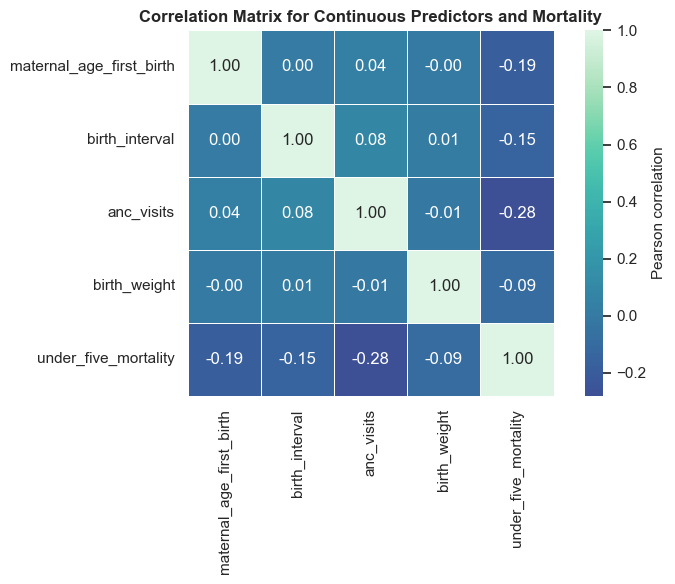

In [76]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="mako",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Pearson correlation"},
)

plt.title(
    "Correlation Matrix for Continuous Predictors and Mortality"
)
plt.tight_layout()
plt.show()

### Check Correlation Between Predictors

In [78]:
predictor_correlation = data[continuous_vars].corr()

high_correlation_pairs = []

for first_index, first_variable in enumerate(continuous_vars):
    for second_index in range(
        first_index + 1,
        len(continuous_vars)
    ):
        second_variable = continuous_vars[second_index]

        correlation_value = predictor_correlation.loc[
            first_variable,
            second_variable,
        ]

        if abs(correlation_value) >= 0.70:
            high_correlation_pairs.append({
                "Variable 1": first_variable,
                "Variable 2": second_variable,
                "Correlation": correlation_value,
            })

if high_correlation_pairs:
    display(
        pd.DataFrame(high_correlation_pairs).round(3)
    )
else:
    print(
        "No continuous predictor pair has an absolute "
        "correlation of 0.70 or higher."
    )

No continuous predictor pair has an absolute correlation of 0.70 or higher.


# Training and Test Data Splitting
### Recreate the Predictor Matrix and Outcome Vector

In [80]:
# Outcome variable
target = "under_five_mortality"

# Predictor variables
predictor_vars = continuous_vars + categorical_vars

# Create X and y from the cleaned data
X = data[predictor_vars].copy()
y = data[target].copy()

print("Predictor matrix shape:", X.shape)
print("Outcome vector shape:", y.shape)

Predictor matrix shape: (5115, 13)
Outcome vector shape: (5115,)


### Confirm That the Outcome Is Not Among the Predictors

In [82]:
print("Predictor variables:", X.columns.tolist())

Predictor variables: ['maternal_age_first_birth', 'birth_interval', 'anc_visits', 'birth_weight', 'maternal_education', 'maternal_health_status', 'birth_order', 'wealth_index', 'multiple_birth', 'child_sex', 'birth_assistance', 'residence', 'marital_status']


### Examine the Outcome Before Splitting

In [84]:
before_split_distribution = pd.DataFrame({
    "Frequency": y.value_counts().sort_index(),
    "Percentage": (
        y.value_counts(normalize=True)
        .sort_index()
        .mul(100)
    ),
})

before_split_distribution.index = (
    before_split_distribution.index.map({
        0: "Alive (0)",
        1: "Under-five death (1)",
    })
)

display(before_split_distribution.round(2))

,Frequency,Percentage
under_five_mortality,,
Alive (0),3887,75.99
Under-five death (1),1228,24.01


### Splitting Parameters

In [86]:
RANDOM_STATE = 42
TEST_SIZE = 0.30

print(f"Training proportion: {(1 - TEST_SIZE):.0%}")
print(f"Test proportion: {TEST_SIZE:.0%}")
print(f"Random state: {RANDOM_STATE}")

Training proportion: 70%
Test proportion: 30%
Random state: 42


### Perform the Stratified Split

In [88]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

### Display the Split Dimensions

In [90]:
split_dimensions = pd.DataFrame({
    "Dataset": [
        "Complete predictor data",
        "Training predictors",
        "Test predictors",
        "Training outcome",
        "Test outcome",
    ],
    "Rows": [
        X.shape[0],
        X_train.shape[0],
        X_test.shape[0],
        y_train.shape[0],
        y_test.shape[0],
    ],
    "Columns": [
        X.shape[1],
        X_train.shape[1],
        X_test.shape[1],
        1,
        1,
    ],
})

display(split_dimensions)

,Dataset,Rows,Columns
0,Complete predictor data,5115,13
1,Training predictors,3580,13
2,Test predictors,1535,13
3,Training outcome,3580,1
4,Test outcome,1535,1


## Compare the Class Distributions

In [92]:
def calculate_class_distribution(
    outcome,
    dataset_name,
):
    distribution = pd.DataFrame({
        "Frequency": outcome.value_counts().sort_index(),
        "Percentage": (
            outcome.value_counts(normalize=True)
            .sort_index()
            .mul(100)
        ),
    })

    distribution["Dataset"] = dataset_name
    distribution["Outcome code"] = distribution.index

    return distribution.reset_index(drop=True)


full_distribution = calculate_class_distribution(
    y,
    "Complete data",
)

training_distribution = calculate_class_distribution(
    y_train,
    "Training data",
)

test_distribution = calculate_class_distribution(
    y_test,
    "Test data",
)

split_class_distribution = pd.concat(
    [
        full_distribution,
        training_distribution,
        test_distribution,
    ],
    ignore_index=True,
)

split_class_distribution["Outcome"] = (
    split_class_distribution["Outcome code"].map({
        0: "Alive",
        1: "Under-five death",
    })
)

split_class_distribution = split_class_distribution[
    [
        "Dataset",
        "Outcome code",
        "Outcome",
        "Frequency",
        "Percentage",
    ]
]

display(split_class_distribution.round(2))

,Dataset,Outcome code,Outcome,Frequency,Percentage
0,Complete data,0,Alive,3887,75.99
1,Complete data,1,Under-five death,1228,24.01
2,Training data,0,Alive,2721,76.01
3,Training data,1,Under-five death,859,23.99
4,Test data,0,Alive,1166,75.96
5,Test data,1,Under-five death,369,24.04


## Visualize the Class Distribution

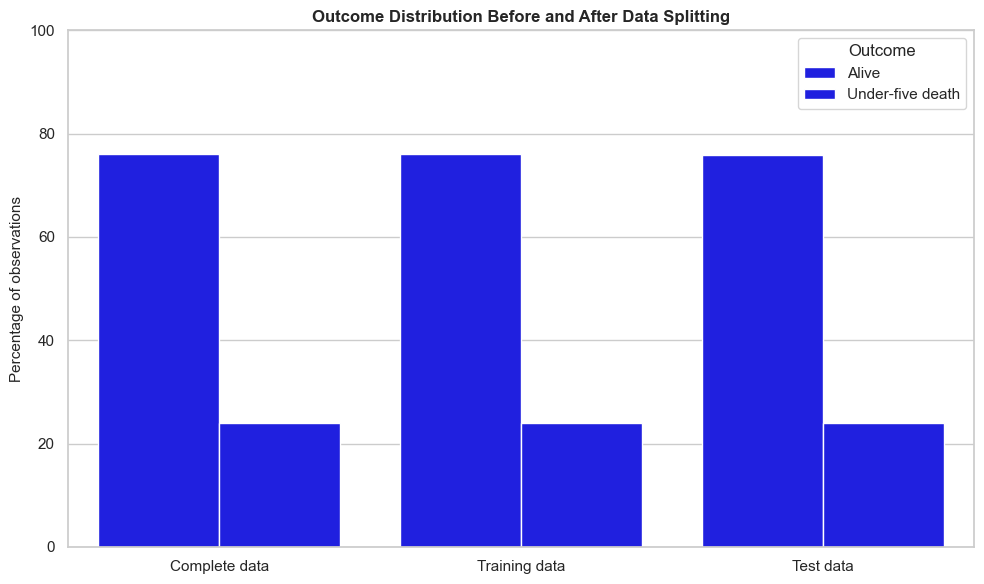

In [94]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=split_class_distribution,
    x="Dataset",
    y="Percentage",
    hue="Outcome",
    palette={
        "Alive": "blue",
        "Under-five death": "blue",
    },
)

plt.title("Outcome Distribution Before and After Data Splitting")
plt.xlabel("")
plt.ylabel("Percentage of observations")
plt.ylim(0, 100)
plt.legend(title="Outcome")
plt.tight_layout()
plt.show()

## Confirm That Training and Test Observations Do Not Overlap

In [96]:
overlapping_indices = X_train.index.intersection(
    X_test.index
)

if len(overlapping_indices) > 0:
    raise ValueError(
        "Training and test datasets contain overlapping observations."
    )

print("Number of overlapping observations:", len(overlapping_indices))

Number of overlapping observations: 0


## Inspect Missing Values After Splitting

In [98]:
training_missing = X_train.isna().sum()
test_missing = X_test.isna().sum()

missing_by_split = pd.DataFrame({
    "Training missing": training_missing,
    "Training missing (%)": (
        X_train.isna().mean() * 100
    ),
    "Test missing": test_missing,
    "Test missing (%)": (
        X_test.isna().mean() * 100
    ),
})

missing_by_split = missing_by_split.loc[
    (
        missing_by_split["Training missing"] > 0
    )
    | (
        missing_by_split["Test missing"] > 0
    )
]

display(missing_by_split.round(2))

,Training missing,Training missing (%),Test missing,Test missing (%)
birth_interval,14,0.39,9,0.59
anc_visits,69,1.93,21,1.37
birth_weight,40,1.12,17,1.11
birth_assistance,11,0.31,4,0.26


# Leakage-Safe Data Preprocessing
## Import the Required Preprocessing Libraries

In [100]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

## Confirm the Predictor Groups

In [102]:
print("Continuous predictors:")

for variable in continuous_vars:
    print(f"  - {variable}")

print("\nCategorical predictors:")

for variable in categorical_vars:
    print(f"  - {variable}")

Continuous predictors:
  - maternal_age_first_birth
  - birth_interval
  - anc_visits
  - birth_weight

Categorical predictors:
  - maternal_education
  - maternal_health_status
  - birth_order
  - wealth_index
  - multiple_birth
  - child_sex
  - birth_assistance
  - residence
  - marital_status


## Create the Numerical Preprocessing Pipeline

In [104]:
numerical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median"),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
    ]
)
print(numerical_transformer)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])


## Create the Categorical Preprocessing Pipeline

In [106]:
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent"),
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True,
            ),
        ),
    ]
)

print(categorical_transformer)

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore'))])


## Combine Both Pipelines

In [108]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numerical_transformer,
            continuous_vars,
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_vars,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=True,
)

## Recommended Reusable Preprocessor Function

In [110]:
def build_preprocessor():
    """
    Create a new, unfitted preprocessing pipeline.

    Returns
    -------
    ColumnTransformer
        Preprocessor for numerical and categorical predictors.
    """

    numeric_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="median"),
            ),
            (
                "scaler",
                StandardScaler(),
            ),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="most_frequent"),
            ),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=True,
                ),
            ),
        ]
    )

    return ColumnTransformer(
        transformers=[
            (
                "numeric",
                numeric_pipeline,
                continuous_vars,
            ),
            (
                "categorical",
                categorical_pipeline,
                categorical_vars,
            ),
        ],
        remainder="drop",
        verbose_feature_names_out=True,
    )

preprocessor = build_preprocessor()

## Preprocessing Design Summary

In [112]:
preprocessing_summary = pd.DataFrame({
    "Predictor group": [
        "Continuous",
        "Continuous",
        "Categorical",
        "Categorical",
    ],
    "Operation": [
        "Missing-value imputation",
        "Standardization",
        "Missing-value imputation",
        "One-hot encoding",
    ],
    "Method": [
        "Training median",
        "StandardScaler",
        "Training most-frequent category",
        "OneHotEncoder",
    ],
    "Reason": [
        "Robust to extreme numerical values",
        "Places numerical predictors on comparable scales",
        "Suitable for limited categorical missingness",
        "Converts categories into model-compatible indicators",
    ],
})

display(preprocessing_summary)

,Predictor group,Operation,Method,Reason
0,Continuous,Missing-value imputation,Training median,Robust to extreme numerical values
1,Continuous,Standardization,StandardScaler,Places numerical predictors on comparable scales
2,Categorical,Missing-value imputation,Training most-frequent category,Suitable for limited categorical missingness
3,Categorical,One-hot encoding,OneHotEncoder,Converts categories into model-compatible indi...


# Handling Class Imbalance using SMOTENC
## Required imports

In [114]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
)
from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline

In [115]:
for column in categorical_vars:
    X_train[column] = (
        X_train[column]
        .astype(object)
        .where(X_train[column].notna(), np.nan)
    )

    X_test[column] = (
        X_test[column]
        .astype(object)
        .where(X_test[column].notna(), np.nan)
    )

## Create the complete pipeline

In [117]:
def build_model_pipeline(model):

    numeric_indices = list(
        range(len(continuous_vars))
    )

    categorical_indices = list(
        range(
            len(continuous_vars),
            len(continuous_vars) + len(categorical_vars)
        )
    )

    before_smote = ColumnTransformer([
        (
            "numeric",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            continuous_vars,
        ),
        (
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(
                    strategy="most_frequent"
                )),
                ("ordinal", OrdinalEncoder(
                    handle_unknown="use_encoded_value",
                    unknown_value=-1,
                )),
            ]),
            categorical_vars,
        ),
    ])

    after_smote = ColumnTransformer([
        ("numeric", "passthrough", numeric_indices),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_indices,
        ),
    ])

    return ImbPipeline([
        ("pre_smote", before_smote),
        (
            "smotenc",
            SMOTENC(
                categorical_features=categorical_indices,
                sampling_strategy="auto",
                random_state=RANDOM_STATE,
                k_neighbors=5,
            ),
        ),
        ("post_smote", after_smote),
        ("model", model),
    ])

## Verify the class distribution

In [119]:
from collections import Counter
from sklearn.linear_model import LogisticRegression

pipeline = build_model_pipeline(
    LogisticRegression(max_iter=1000)
)

X_encoded = (
    pipeline.named_steps["pre_smote"]
    .fit_transform(X_train)
)

X_resampled, y_resampled = (
    pipeline.named_steps["smotenc"]
    .fit_resample(X_encoded, y_train)
)

print("Before SMOTENC:", Counter(y_train))
print("After SMOTENC:", Counter(y_resampled))

Before SMOTENC: Counter({0: 2721, 1: 859})
After SMOTENC: Counter({0: 2721, 1: 2721})


# Model Training
## Logistic Regression Training

### Evaluation function

In [122]:
def evaluate_cv_model(estimator, model_name):
    from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    StratifiedKFold,
    cross_validate,
    cross_val_predict
)

    from sklearn.metrics import (
    make_scorer,
    recall_score,
    cohen_kappa_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)
    RANDOM_STATE = 42

    repeated_cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=3,
    random_state=RANDOM_STATE
)

    oof_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

    scoring = {
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "specificity": make_scorer(
            recall_score,
            pos_label=0
        ),
        "f1": "f1",
        "roc_auc": "roc_auc",
        "kappa": make_scorer(cohen_kappa_score)
    }

    # Repeated stratified 5-fold CV metrics
    cv_results = cross_validate(
        estimator,
        X_train,
        y_train,
        cv=repeated_cv,
        scoring=scoring,
        n_jobs=-1,
        error_score="raise"
    )

    results = {
        "Model": model_name,
        "Accuracy": cv_results["test_accuracy"].mean(),
        "Precision": cv_results["test_precision"].mean(),
        "Recall": cv_results["test_recall"].mean(),
        "Specificity": cv_results["test_specificity"].mean(),
        "F1-score": cv_results["test_f1"].mean(),
        "ROC-AUC": cv_results["test_roc_auc"].mean(),
        "Kappa": cv_results["test_kappa"].mean()
    }

    display(pd.DataFrame([results]).round(4))

    # Predictions for confusion matrix
    y_pred = cross_val_predict(
        estimator,
        X_train,
        y_train,
        cv=oof_cv,
        method="predict",
        n_jobs=-1
    )

    # Probabilities for ROC curve
    y_prob = cross_val_predict(
        estimator,
        X_train,
        y_train,
        cv=oof_cv,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]

    ConfusionMatrixDisplay.from_predictions(
        y_train,
        y_pred,
        display_labels=["Alive", "Death"],
        cmap="Blues"
    )

    plt.title(f"Confusion Matrix: {model_name}")
    plt.show()

    RocCurveDisplay.from_predictions(
        y_train,
        y_prob,
        name=model_name
    )

    plt.title(f"ROC Curve: {model_name}")
    plt.show()

    return results

### Training Logistic model

In [124]:
logistic_baseline = build_model_pipeline(
    LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    )
)

logistic_baseline.fit(X_train, y_train)

logistic_baseline

,steps,"[('pre_smote', ...), ('smotenc', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int32](2,)","[0,1]"
feature_names_in_,"ndarray[object](13,)","['maternal_age_first_birth','birth_interval','anc_visits',..., 'birth_assistance','residence','marital_status']"
n_features_in_,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


### Evaluation of the model

,Model,Accuracy,Precision,Recall,Specificity,F1-score,ROC-AUC,Kappa
0,Baseline Logistic Regression,0.807,0.5689,0.8141,0.8047,0.6694,0.8886,0.5392


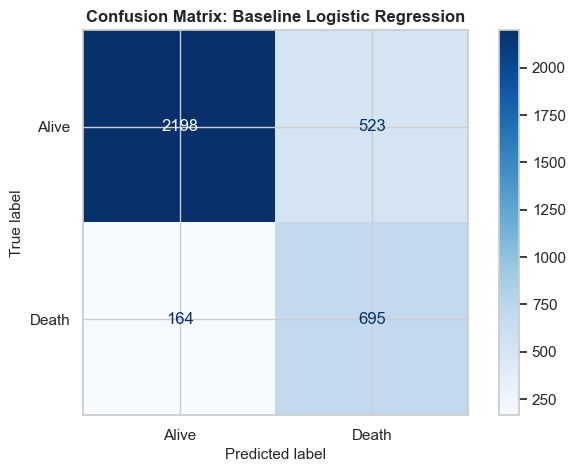

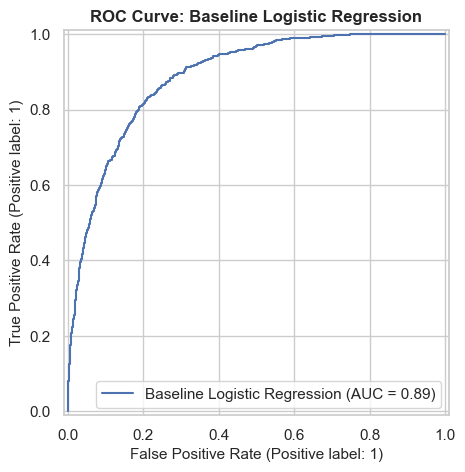

In [ ]:
logistic_baseline_metrics = evaluate_cv_model(
    logistic_baseline,
    "Baseline Logistic Regression"
)

### Save the baseline model

In [128]:
from pathlib import Path

MODEL_DIR = Path.cwd() / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(
    logistic_baseline,
    MODEL_DIR / "logistic_baseline.joblib"
)

['C:\\Users\\User\\Desktop\\2026\\Thesis\\data\\My App\\models\\logistic_baseline.joblib']

### Hyperparameter tuning of the baseline logistic model

In [130]:
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold

RANDOM_STATE = 42

# Repeated stratified 5-fold cross-validation
repeated_cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=3,
    random_state=RANDOM_STATE
)

logistic_tuning_pipeline = build_model_pipeline(
    LogisticRegression(
        max_iter=1000,
        solver="liblinear",
        random_state=RANDOM_STATE
    )
)

logistic_param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l1", "l2"]
}

logistic_grid = GridSearchCV(
    estimator=logistic_tuning_pipeline,
    param_grid=logistic_param_grid,
    scoring={
        "recall": "recall",
        "roc_auc": "roc_auc",
        "f1": "f1",
        "precision": "precision"
    },
    refit="recall",
    cv=repeated_cv,
    n_jobs=-1,
    error_score="raise"
)

logistic_grid.fit(X_train, y_train)

print("Best parameters:", logistic_grid.best_params_)
print("Best CV recall:", round(logistic_grid.best_score_, 4))

Best parameters: {'model__C': 0.01, 'model__penalty': 'l2'}
Best CV recall: 0.8137


### Evaluate the tuned model

,Model,Accuracy,Precision,Recall,Specificity,F1-score,ROC-AUC,Kappa
0,Tuned Logistic Regression,0.7895,0.5411,0.8137,0.7818,0.6497,0.8781,0.5079


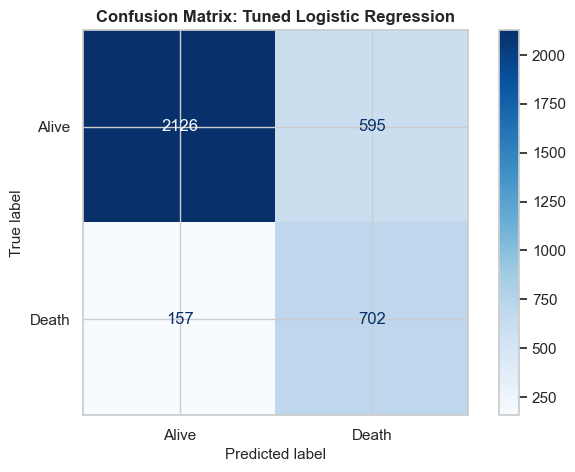

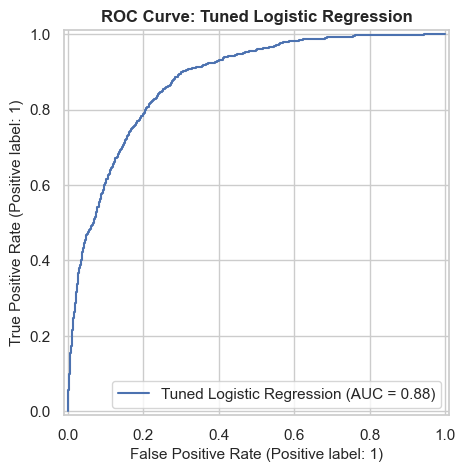

In [132]:
logistic_tuned = logistic_grid.best_estimator_

logistic_tuned_metrics = evaluate_cv_model(
    logistic_tuned,
    "Tuned Logistic Regression"
)

### Save the tuned model

In [134]:
joblib.dump(
    logistic_tuned,
    MODEL_DIR / "logistic_tuned.joblib"
)

['C:\\Users\\User\\Desktop\\2026\\Thesis\\data\\My App\\models\\logistic_tuned.joblib']

### Compare baseline and tuned results

In [136]:
logistic_comparison = pd.DataFrame([
    logistic_baseline_metrics,
    logistic_tuned_metrics
])

display(
    logistic_comparison.set_index("Model").round(4)
)

,Accuracy,Precision,Recall,Specificity,F1-score,ROC-AUC,Kappa
Model,,,,,,,
Baseline Logistic Regression,0.8070,0.5689,0.8141,0.8047,0.6694,0.8886,0.5392
Tuned Logistic Regression,0.7895,0.5411,0.8137,0.7818,0.6497,0.8781,0.5079


## SVM Training

## Import Libraries

In [139]:
from sklearn.svm import SVC
from sklearn.model_selection import (
    GridSearchCV,
    RepeatedStratifiedKFold,
    StratifiedKFold
)

RANDOM_STATE = 42

# Used for model evaluation and tuning
repeated_cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=3,
    random_state=RANDOM_STATE
)

# Used for confusion matrix and ROC curve
oof_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

## Training the SVM Model

In [141]:
svm_model = build_model_pipeline(
    SVC(
        kernel="rbf",
        probability=True,
        random_state=RANDOM_STATE
    )
)

svm_model.fit(X_train, y_train)

svm_model

,steps,"[('pre_smote', ...), ('smotenc', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int32](2,)","[0,1]"
feature_names_in_,"ndarray[object](13,)","['maternal_age_first_birth','birth_interval','anc_visits',..., 'birth_assistance','residence','marital_status']"
n_features_in_,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


In [142]:
## Saving the SVM Model
joblib.dump(
    svm_model,
    MODEL_DIR / "svm_model.joblib"
)

['C:\\Users\\User\\Desktop\\2026\\Thesis\\data\\My App\\models\\svm_model.joblib']

## SVM Model Evaluation

,Model,Accuracy,Precision,Recall,Specificity,F1-score,ROC-AUC,Kappa
0,SVM,0.8139,0.5841,0.7823,0.8238,0.6685,0.8875,0.543


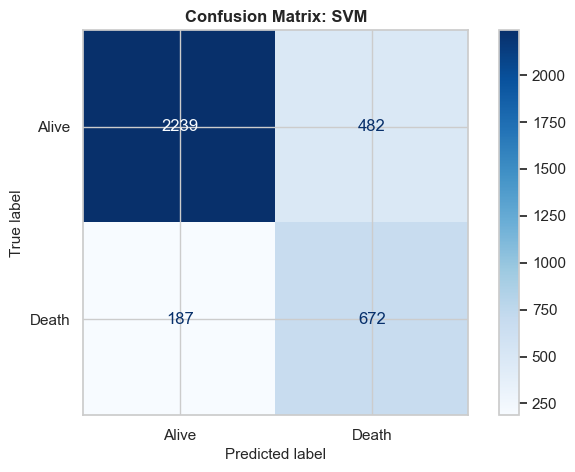

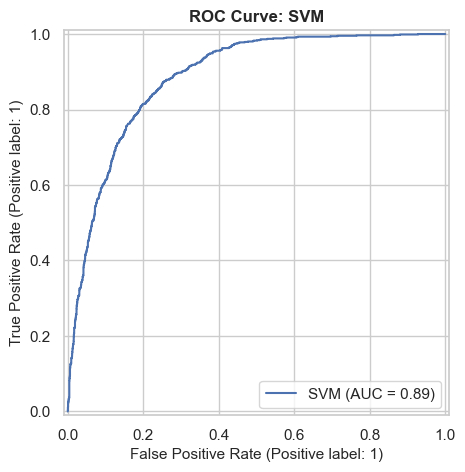

In [144]:
svm_metrics = evaluate_cv_model(
    svm_model,
    "SVM"
)

## Tuning the SVM Model

In [146]:
svm_tuning_pipeline = build_model_pipeline(
    SVC(
        probability=True,
        random_state=RANDOM_STATE
    )
)

svm_param_grid = [
    {
        "model__kernel": ["linear"],
        "model__C": [0.1, 1, 10]
    },
    {
        "model__kernel": ["rbf"],
        "model__C": [0.1, 1, 10],
        "model__gamma": ["scale", 0.01, 0.1]
    }
]

svm_grid = GridSearchCV(
    estimator=svm_tuning_pipeline,
    param_grid=svm_param_grid,
    scoring={
        "recall": "recall",
        "roc_auc": "roc_auc",
        "f1": "f1",
        "precision": "precision"
    },
    refit="recall",
    cv=repeated_cv,
    n_jobs=-1,
    error_score="raise"
)

svm_grid.fit(X_train, y_train)

print("Best parameters:", svm_grid.best_params_)
print("Best CV recall:", round(svm_grid.best_score_, 4))

Best parameters: {'model__C': 0.1, 'model__gamma': 0.01, 'model__kernel': 'rbf'}
Best CV recall: 0.8409


In [147]:
## Save the tuned model
svm_tuned = svm_grid.best_estimator_

svm_tuned
joblib.dump(
    svm_tuned,
    MODEL_DIR / "svm_tuned.joblib"
)

['C:\\Users\\User\\Desktop\\2026\\Thesis\\data\\My App\\models\\svm_tuned.joblib']

## Evaluate the tuned SVM model

,Model,Accuracy,Precision,Recall,Specificity,F1-score,ROC-AUC,Kappa
0,Tuned SVM,0.766,0.5077,0.8409,0.7424,0.6329,0.8688,0.4762


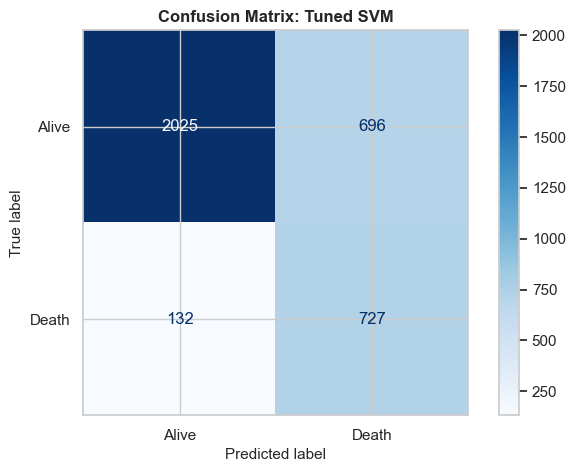

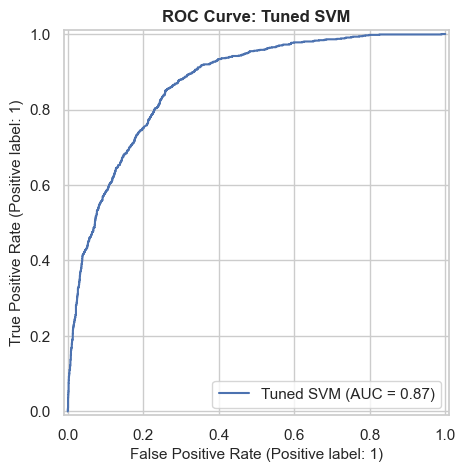

In [149]:
svm_tuned = svm_grid.best_estimator_

svm_tuned_metrics = evaluate_cv_model(
    svm_tuned,
    "Tuned SVM"
)

## Compare SVM before and after tuning

In [151]:
svm_comparison = pd.DataFrame([
    svm_metrics,
    svm_tuned_metrics
])

display(
    svm_comparison.set_index("Model").round(4)
)

,Accuracy,Precision,Recall,Specificity,F1-score,ROC-AUC,Kappa
Model,,,,,,,
SVM,0.8139,0.5841,0.7823,0.8238,0.6685,0.8875,0.5430
Tuned SVM,0.7660,0.5077,0.8409,0.7424,0.6329,0.8688,0.4762


## Random Forest Model

In [153]:
from sklearn.ensemble import RandomForestClassifier
rf_model = build_model_pipeline(
    RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=1
    )
)

rf_model.fit(X_train, y_train)

rf_model

,steps,"[('pre_smote', ...), ('smotenc', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int32](2,)","[0,1]"
feature_names_in_,"ndarray[object](13,)","['maternal_age_first_birth','birth_interval','anc_visits',..., 'birth_assistance','residence','marital_status']"
n_features_in_,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


In [154]:
# Save the trained model
joblib.dump(
    rf_model,
    MODEL_DIR / "random_forest_model.joblib"
)

['C:\\Users\\User\\Desktop\\2026\\Thesis\\data\\My App\\models\\random_forest_model.joblib']

## Evaluate the Random Forest

,Model,Accuracy,Precision,Recall,Specificity,F1-score,ROC-AUC,Kappa
0,Random Forest,0.8277,0.6359,0.6593,0.8808,0.6467,0.8858,0.5329


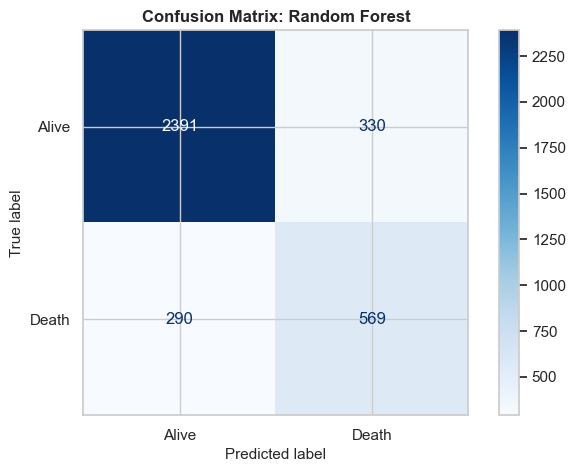

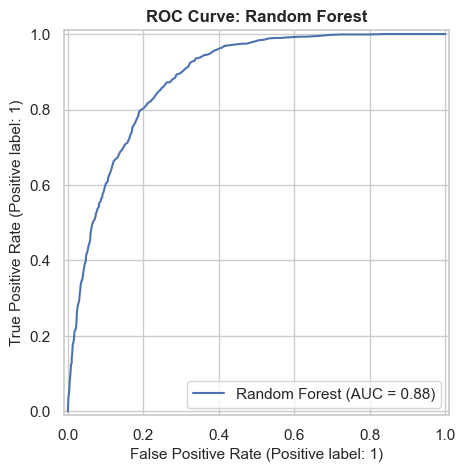

In [156]:
rf_metrics = evaluate_cv_model(
    rf_model,
    "Random Forest"
)

## Hyperparameter Tuning of the random forest

In [158]:
rf_tuning_pipeline = build_model_pipeline(
    RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=1
    )
)

rf_param_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(
    estimator=rf_tuning_pipeline,
    param_grid=rf_param_grid,
    scoring={
        "recall": "recall",
        "roc_auc": "roc_auc",
        "f1": "f1",
        "precision": "precision"
    },
    refit="recall",
    cv=repeated_cv,
    n_jobs=-1,
    error_score="raise"
)

rf_grid.fit(X_train, y_train)

print("Best parameters:", rf_grid.best_params_)
print("Best CV recall:", round(rf_grid.best_score_, 4))

Best parameters: {'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 400}
Best CV recall: 0.761


## Evaluate the Tuned Random Forest

,Model,Accuracy,Precision,Recall,Specificity,F1-score,ROC-AUC,Kappa
0,Tuned Random Forest,0.7966,0.5559,0.761,0.8079,0.6421,0.8829,0.5049


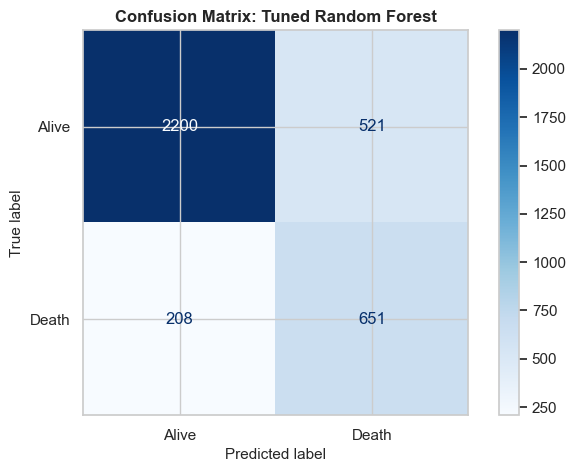

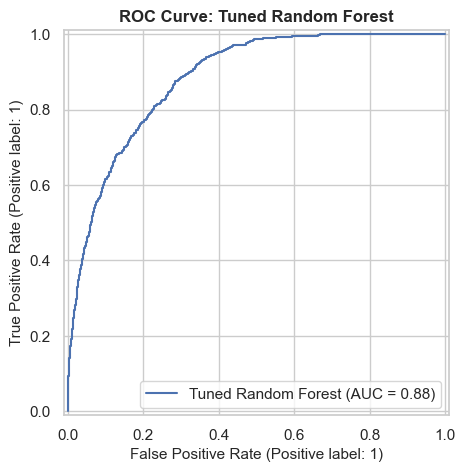

In [160]:
rf_tuned = rf_grid.best_estimator_

rf_tuned_metrics = evaluate_cv_model(
    rf_tuned,
    "Tuned Random Forest"
)

## Save the Tuned Model

In [162]:
joblib.dump(
    rf_tuned,
    MODEL_DIR / "random_forest_tuned.joblib"
)

['C:\\Users\\User\\Desktop\\2026\\Thesis\\data\\My App\\models\\random_forest_tuned.joblib']

## Compare Initial and Tuned Random Forest

In [164]:
rf_comparison = pd.DataFrame([
    rf_metrics,
    rf_tuned_metrics
])

display(
    rf_comparison
    .set_index("Model")
    .round(4)
)

,Accuracy,Precision,Recall,Specificity,F1-score,ROC-AUC,Kappa
Model,,,,,,,
Random Forest,0.8277,0.6359,0.6593,0.8808,0.6467,0.8858,0.5329
Tuned Random Forest,0.7966,0.5559,0.7610,0.8079,0.6421,0.8829,0.5049


## XGBoost Model Training

In [166]:
xgb_model = build_model_pipeline(
    XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=1
    )
)

xgb_model.fit(X_train, y_train)

xgb_model

,steps,"[('pre_smote', ...), ('smotenc', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int32](2,)","[0,1]"
feature_names_in_,"ndarray[object](13,)","['maternal_age_first_birth','birth_interval','anc_visits',..., 'birth_assistance','residence','marital_status']"
n_features_in_,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


In [167]:
## Save the XGBoost
joblib.dump(
    xgb_model,
    MODEL_DIR / "xgboost_model.joblib"
)

['C:\\Users\\User\\Desktop\\2026\\Thesis\\data\\My App\\models\\xgboost_model.joblib']

## Evaluate the XGBoost Model

,Model,Accuracy,Precision,Recall,Specificity,F1-score,ROC-AUC,Kappa
0,XGBoost,0.836,0.6318,0.7594,0.8602,0.6891,0.9048,0.5791


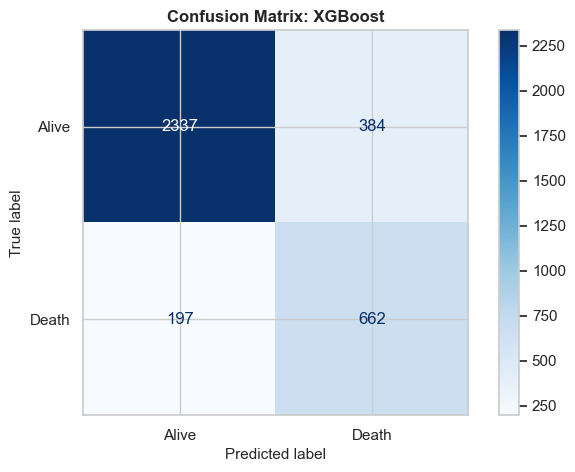

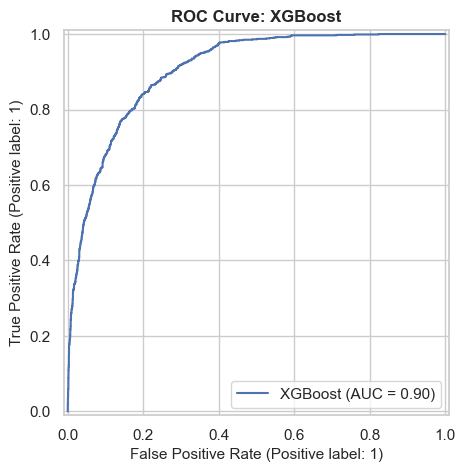

In [169]:
xgb_metrics = evaluate_cv_model(
    xgb_model,
    "XGBoost"
)

## Hyperparameter Tuning

In [171]:
xgb_tuning_pipeline = build_model_pipeline(
    XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=1
    )
)

xgb_param_grid = {
    "model__n_estimators": [200, 400],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [3, 5],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8]
}

xgb_grid = GridSearchCV(
    estimator=xgb_tuning_pipeline,
    param_grid=xgb_param_grid,
    scoring={
        "recall": "recall",
        "roc_auc": "roc_auc",
        "f1": "f1",
        "precision": "precision"
    },
    refit="recall",
    cv=repeated_cv,
    n_jobs=-1,
    error_score="raise"
)

xgb_grid.fit(X_train, y_train)

print("Best parameters:", xgb_grid.best_params_)
print("Best CV recall:", round(xgb_grid.best_score_, 4))

Best parameters: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 1.0}
Best CV recall: 0.7594


## Evaluate the Tuned XGBoost Model

,Model,Accuracy,Precision,Recall,Specificity,F1-score,ROC-AUC,Kappa
0,Tuned XGBoost,0.8353,0.6303,0.7594,0.8592,0.6883,0.905,0.5777


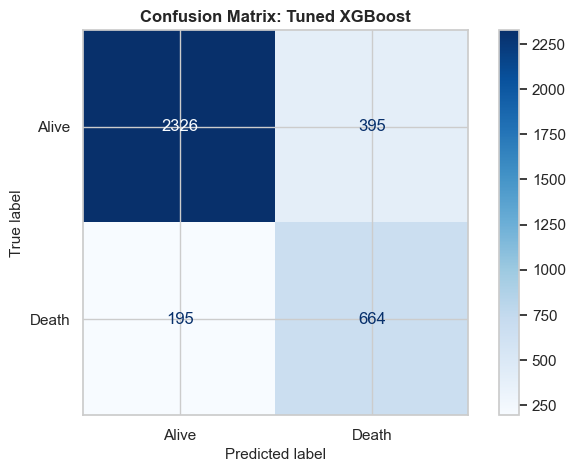

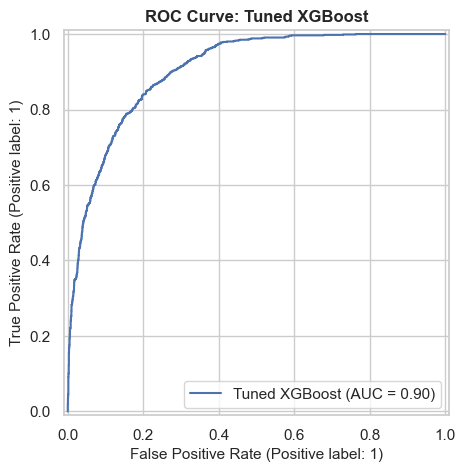

In [173]:
xgb_tuned = xgb_grid.best_estimator_

xgb_tuned_metrics = evaluate_cv_model(
    xgb_tuned,
    "Tuned XGBoost"
)

## Save the Tuned Model

In [175]:
joblib.dump(
    xgb_tuned,
    MODEL_DIR / "xgboost_tuned.joblib"
)

['C:\\Users\\User\\Desktop\\2026\\Thesis\\data\\My App\\models\\xgboost_tuned.joblib']

## Compare Initial and Tuned XGBoost

In [177]:
xgb_comparison = pd.DataFrame([
    xgb_metrics,
    xgb_tuned_metrics
])

display(
    xgb_comparison
    .set_index("Model")
    .round(4)
)

,Accuracy,Precision,Recall,Specificity,F1-score,ROC-AUC,Kappa
Model,,,,,,,
XGBoost,0.8360,0.6318,0.7594,0.8602,0.6891,0.9048,0.5791
Tuned XGBoost,0.8353,0.6303,0.7594,0.8592,0.6883,0.9050,0.5777


## Compare All Initial Models

In [340]:
initial_models_comparison = (
    pd.DataFrame([
        logistic_baseline_metrics,
        svm_metrics,
        rf_metrics,
        xgb_metrics
    ])
    .sort_values(
        by=["Recall", "ROC-AUC"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

display(
    initial_models_comparison
    .set_index("Model")
    .round(4)
    .style.highlight_max(
        subset=[
            "Accuracy",
            "Precision",
            "Recall",
            "Specificity",
            "F1-score",
            "ROC-AUC",
            "Kappa"
        ],
        color="white"
    )
)

,Accuracy,Precision,Recall,Specificity,F1-score,ROC-AUC,Kappa
Model,,,,,,,
Baseline Logistic Regression,0.807000,0.568900,0.814100,0.804700,0.669400,0.888600,0.539200
SVM,0.813900,0.584100,0.782300,0.823800,0.668500,0.887500,0.543000
XGBoost,0.836000,0.631800,0.759400,0.860200,0.689100,0.904800,0.579100
Random Forest,0.827700,0.635900,0.659300,0.880800,0.646700,0.885800,0.532900


## Compare All Tuned Models

In [342]:
tuned_models_comparison = pd.DataFrame([
    logistic_tuned_metrics,
    svm_tuned_metrics,
    rf_tuned_metrics,
    xgb_tuned_metrics
])

tuned_models_comparison = tuned_models_comparison.sort_values(
    by=["Recall", "ROC-AUC"],
    ascending=False
)

display(
    tuned_models_comparison
    .set_index("Model")
    .round(4)
)

,Accuracy,Precision,Recall,Specificity,F1-score,ROC-AUC,Kappa
Model,,,,,,,
Tuned SVM,0.7660,0.5077,0.8409,0.7424,0.6329,0.8688,0.4762
Tuned Logistic Regression,0.7895,0.5411,0.8137,0.7818,0.6497,0.8781,0.5079
Tuned Random Forest,0.7966,0.5559,0.7610,0.8079,0.6421,0.8829,0.5049
Tuned XGBoost,0.8353,0.6303,0.7594,0.8592,0.6883,0.9050,0.5777


## Highlight the Highest Metric Values

In [183]:
display(
    tuned_models_comparison
    .set_index("Model")
    .round(4)
    .style.highlight_max(
        subset=[
            "Accuracy",
            "Precision",
            "Recall",
            "Specificity",
            "F1-score",
            "ROC-AUC",
            "Kappa"
        ],
        color="lightgreen"
    )
)

,Accuracy,Precision,Recall,Specificity,F1-score,ROC-AUC,Kappa
Model,,,,,,,
Tuned SVM,0.766000,0.507700,0.840900,0.742400,0.632900,0.868800,0.476200
Tuned Logistic Regression,0.789500,0.541100,0.813700,0.781800,0.649700,0.878100,0.507900
Tuned Random Forest,0.796600,0.555900,0.761000,0.807900,0.642100,0.882900,0.504900
Tuned XGBoost,0.835300,0.630300,0.759400,0.859200,0.688300,0.905000,0.577700


## ROC Curves for All Tuned Models

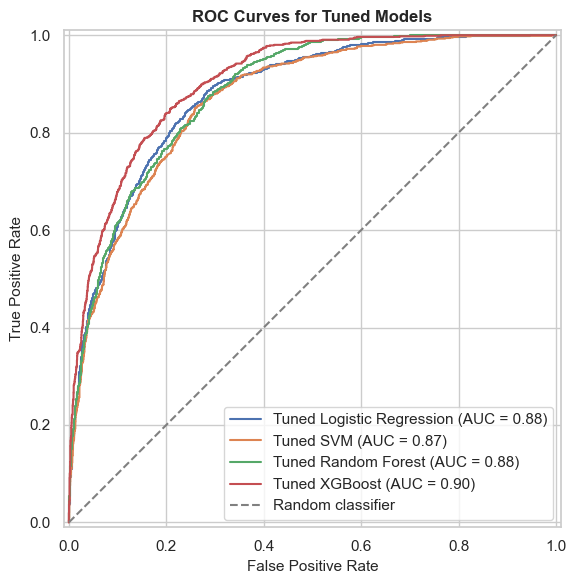

In [185]:
tuned_models = {
    "Tuned Logistic Regression": logistic_tuned,
    "Tuned SVM": svm_tuned,
    "Tuned Random Forest": rf_tuned,
    "Tuned XGBoost": xgb_tuned
}
from sklearn.model_selection import cross_val_predict
fig, ax = plt.subplots(figsize=(8, 6))

for model_name, model in tuned_models.items():

    y_prob = cross_val_predict(
        model,
        X_train,
        y_train,
        cv=oof_cv,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]

    RocCurveDisplay.from_predictions(
        y_train,
        y_prob,
        name=model_name,
        ax=ax
    )

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="grey",
    label="Random classifier"
)

ax.set_title("ROC Curves for Tuned Models")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

## Best model

In [344]:
model_lookup = {
    "Tuned Logistic Regression": logistic_tuned,
    "Tuned SVM": svm_tuned,
    "Tuned Random Forest": rf_tuned,
    "Tuned XGBoost": xgb_tuned
}

best_model_name = "Tuned XGBoost"
best_model = model_lookup[best_model_name]

# Final fit using the complete training dataset
best_model.fit(X_train, y_train)

print("Selected best model:", best_model_name)

Selected best model: Tuned XGBoost


# Explainable AI Using DALEX
## Install and Import DALEX

In [189]:
!pip install dalex
import dalex as dx

## Select the Best Tuned Model

In [346]:
# Final model selected for DALEX
best_model_name = "Tuned XGBoost"
best_model = xgb_tuned

print("Selected model for DALEX:", best_model_name)

Selected model for DALEX: Tuned XGBoost


## Prepare the Original Test Data

In [349]:
X_dalex = X_test.copy()
y_dalex = y_test.to_numpy()

for column in categorical_vars:
    X_dalex[column] = (
        X_dalex[column]
        .astype(object)
        .where(X_dalex[column].notna(), np.nan)
    )

## Create the DALEX Explainer

In [352]:
def mortality_probability(model, data):
    return model.predict_proba(data)[:, 1]


explainer = dx.Explainer(
    model=best_model,
    data=X_dalex,
    y=y_dalex,
    predict_function=mortality_probability,
    label=best_model_name,
    model_type="classification"
)

Preparation of a new explainer is initiated

  -> data              : 1535 rows 13 cols
  -> target variable   : 1535 values
  -> model_class       : xgboost.sklearn.XGBClassifier (default)
  -> label             : Tuned XGBoost
  -> predict function  : <function mortality_probability at 0x0000026A8B27C720> will be used
  -> predict function  : Accepts only pandas.DataFrame, numpy.ndarray causes problems.
  -> predicted values  : min = 0.00213, mean = 0.318, max = 0.989
  -> model type        : classification will be used
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.975, mean = -0.0774, max = 0.976
  -> model_info        : package imblearn

A new explainer has been created!


## Global Variable Importance

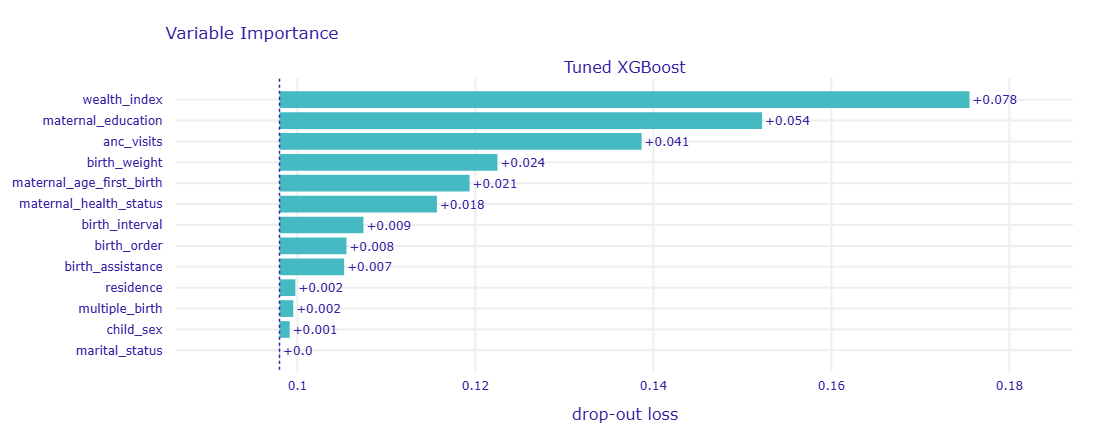

In [355]:
variable_importance = explainer.model_parts(
    type="variable_importance",
    N=1000,
    B=10,
    random_state=RANDOM_STATE
)

variable_importance.plot(
    max_vars=13
)

## Partial Dependence Profiles: Continuous Variables

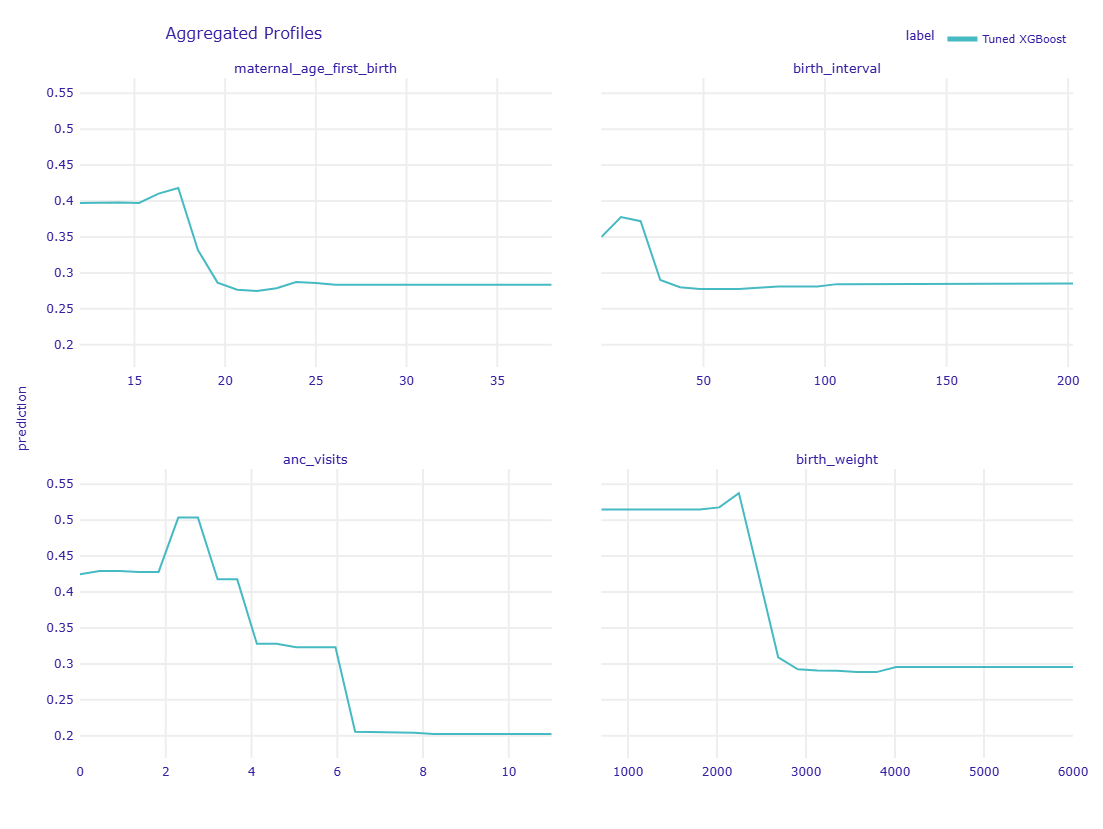

In [358]:
pdp_continuous = explainer.model_profile(
    type="partial",
    variables=continuous_vars,
    variable_type="numerical",
    N=500,
    grid_points=25,
    random_state=RANDOM_STATE,
    verbose=False
)

pdp_continuous.plot()

## Partial Dependence Profiles: Categorical Variables

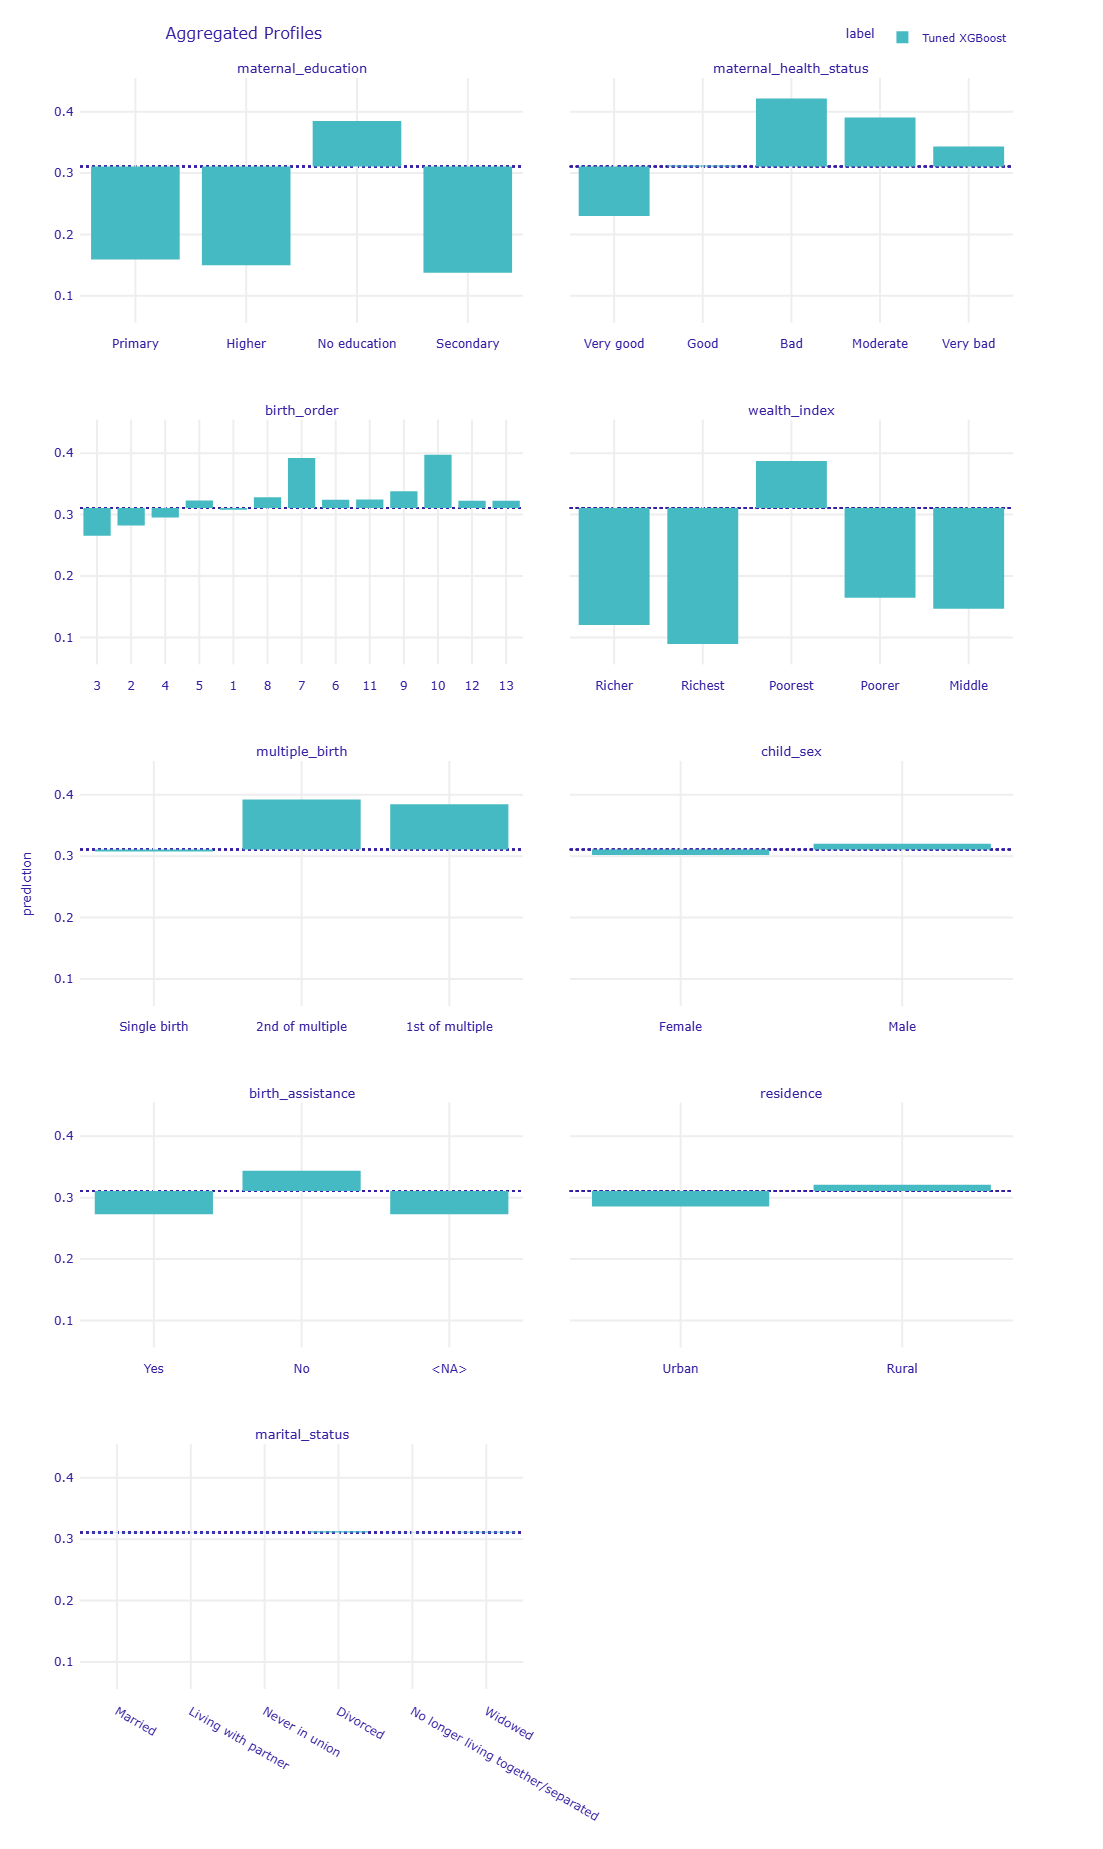

In [361]:
pdp_categorical = explainer.model_profile(
    type="partial",
    variables=categorical_vars,
    variable_type="categorical",
    N=500,
    random_state=RANDOM_STATE,
    verbose=False
)

pdp_categorical.plot()

## Select an Individual High-Risk Case

In [364]:
test_probabilities = best_model.predict_proba(X_dalex)[:, 1]

case_position = np.argmax(test_probabilities)
high_risk_case = X_dalex.iloc[[case_position]]

print("Test row:", high_risk_case.index[0])
print(
    "Predicted mortality probability:",
    round(test_probabilities[case_position], 4)
)
print("Observed outcome:", y_dalex[case_position])

Test row: 2528
Predicted mortality probability: 0.9892
Observed outcome: 1


## Individual Breakdown Plot

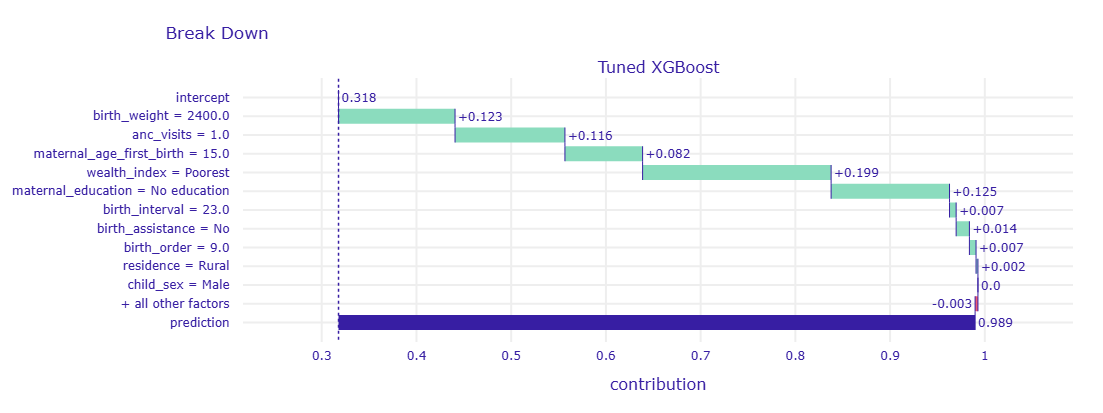

In [367]:
breakdown = explainer.predict_parts(
    new_observation=high_risk_case,
    type="break_down"
)

breakdown.plot()

## Individual SHAP Plot

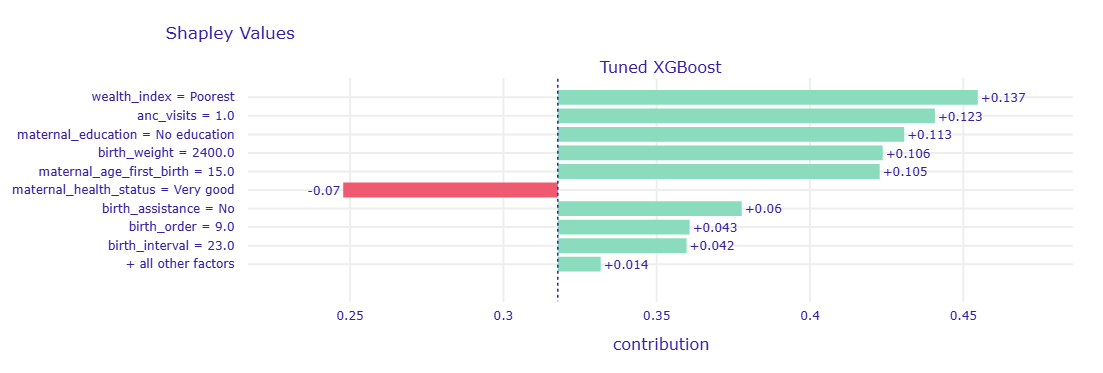

In [370]:
shap_explanation = explainer.predict_parts(
    new_observation=high_risk_case,
    type="shap",
    B=50,
    random_state=RANDOM_STATE
)

shap_explanation.plot()

# TOOL
## Save the Application Files

In [209]:
# Save all tuned pipelines
joblib.dump(logistic_tuned, MODEL_DIR / "logistic_tuned.joblib")
joblib.dump(svm_tuned, MODEL_DIR / "svm_tuned.joblib")
joblib.dump(rf_tuned, MODEL_DIR / "random_forest_tuned.joblib")
joblib.dump(xgb_tuned, MODEL_DIR / "xgboost_tuned.joblib")

feature_order = continuous_vars + categorical_vars

metadata = {
    "feature_order": feature_order,

    "continuous": {
        column: {
            "min": float(X_train[column].min()),
            "max": float(X_train[column].max()),
            "default": float(X_train[column].median())
        }
        for column in continuous_vars
    },

    "categorical": {
        column: sorted(
            X_train[column].dropna().unique().tolist(),
            key=str
        )
        for column in categorical_vars
    },

    "best_model": tuned_models_comparison.iloc[0]["Model"],

    # Temporary research thresholds
    "thresholds": {
        "low": 0.20,
        "high": 0.50
    }
}

joblib.dump(
    metadata,
    MODEL_DIR / "app_metadata.joblib"
)

# Background data required for DALEX
dalex_background = X_train[feature_order].sample(
    n=min(500, len(X_train)),
    random_state=RANDOM_STATE
)

joblib.dump(
    dalex_background,
    MODEL_DIR / "dalex_background.joblib"
)

['C:\\Users\\User\\Desktop\\2026\\Thesis\\data\\My App\\models\\dalex_background.joblib']

## Final Test Evaluation

In [372]:
y_test_pred = best_model.predict(X_test)
y_test_prob = best_model.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_test_pred)
tn, fp, fn, tp = cm.ravel()

final_test_results = pd.DataFrame([{
    "Model": best_model_name,
    "Accuracy": accuracy_score(y_test, y_test_pred),
    "Precision": precision_score(
        y_test, y_test_pred, zero_division=0
    ),
    "Recall": recall_score(
        y_test, y_test_pred, zero_division=0
    ),
    "Specificity": tn / (tn + fp),
    "F1-score": f1_score(
        y_test, y_test_pred, zero_division=0
    ),
    "ROC-AUC": roc_auc_score(y_test, y_test_prob),
    "Kappa": cohen_kappa_score(y_test, y_test_pred)
}])

display(final_test_results.set_index("Model").round(4))

,Accuracy,Precision,Recall,Specificity,F1-score,ROC-AUC,Kappa
Model,,,,,,,
Tuned XGBoost,0.8287,0.6157,0.7642,0.8491,0.682,0.9006,0.5666


## Check Probability Calibration

Brier score: 0.1157


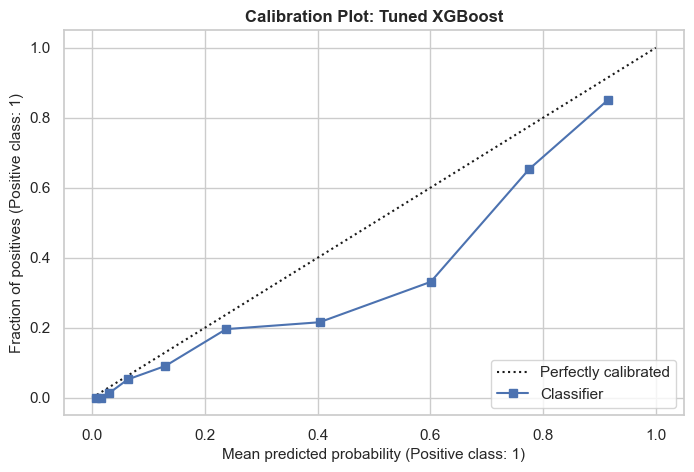

In [374]:
from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import brier_score_loss

print(
    "Brier score:",
    round(brier_score_loss(y_test, y_test_prob), 4)
)

CalibrationDisplay.from_predictions(
    y_test,
    y_test_prob,
    n_bins=10,
    strategy="quantile"
)

plt.title(f"Calibration Plot: {best_model_name}")
plt.show()

# Assistant
The selected code `CalibrationDisplay` refers to a class from scikit-learn's calibration module that is used to visualize the calibration of probabilistic classifiers.

Here's what this class does:

1. **CalibrationDisplay** - This is a visualization tool that creates calibration plots (also known as reliability diagrams) to assess how well-calibrated a model's predicted probabilities are.

2. **Purpose** - It helps evaluate whether the predicted probabilities from a classifier correspond to the actual likelihood of the positive class occurring.

3. **Usage context** - In the code, it's being imported and will be used with the `.from_predictions()` method to generate a calibration plot comparing predicted probabilities (`y_test_prob`) against actual outcomes (`y_test`).